# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, make_scorer, r2_score, root_mean_squared_error

# Import train test split
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from pprint import pprint

# Import Decision Tree Regressor and Classifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

# Import Random Forest Regressor and Classifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

# Import time
import time

# Import Randomized Search CV
from sklearn.model_selection import RandomizedSearchCV

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Import kfold
from sklearn.model_selection import KFold

# Import cross val score
from sklearn.model_selection import cross_val_score

# Import math
import math

# Import log2
from math import log2

# Import classification report
from sklearn.metrics import classification_report

# Import pickle
import pickle

# Import t-SNE and UMAP
from sklearn.manifold import TSNE
import umap

np.random.seed(42)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import the datasets

In [2]:
pickle_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/'

In [3]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_X_train_combined_SMOTE.pkl', 'rb') as f:
    convabuse_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_X_test_combined_SMOTE.pkl', 'rb') as f:
    convabuse_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_y_train_combined_SMOTE.pkl', 'rb') as f:
    convabuse_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_y_test_combined_SMOTE.pkl', 'rb') as f:
    convabuse_y_test = pickle.load(f)

In [4]:
pd.Series(convabuse_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [5]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_agent_X_train_SMOTE.pkl', 'rb') as f:
    convabuse_prev_agent_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_X_test_SMOTE.pkl', 'rb') as f:
    convabuse_prev_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_train_SMOTE.pkl', 'rb') as f:
    convabuse_prev_agent_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_agent_y_test_SMOTE.pkl', 'rb') as f:
    convabuse_prev_agent_y_test = pickle.load(f)

In [6]:
pd.Series(convabuse_prev_agent_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [7]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_prev_user_X_train_SMOTE.pkl', 'rb') as f:
    convabuse_prev_user_X_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_X_test_SMOTE.pkl', 'rb') as f:
    convabuse_prev_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_train_SMOTE.pkl', 'rb') as f:
    convabuse_prev_user_y_train = pickle.load(f)
with open(f'{pickle_path}convabuse_prev_user_y_test_SMOTE.pkl', 'rb') as f:
    convabuse_prev_user_y_test = pickle.load(f)

In [8]:
pd.Series(convabuse_prev_user_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [9]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_agent_X_train_SMOTE.pkl', 'rb') as e:
    convabuse_agent_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_agent_X_test_SMOTE.pkl', 'rb') as f:
    convabuse_agent_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_agent_y_train_SMOTE.pkl', 'rb') as g:
    convabuse_agent_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_agent_y_test_SMOTE.pkl', 'rb') as h:
    convabuse_agent_y_test = pickle.load(h)

In [10]:
pd.Series(convabuse_agent_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [11]:
# Open the pickled embeddings
with open(f'{pickle_path}convabuse_user_X_train_SMOTE.pkl', 'rb') as e:
    convabuse_user_X_train = pickle.load(e)
with open(f'{pickle_path}convabuse_user_X_test_SMOTE.pkl', 'rb') as f:
    convabuse_user_X_test = pickle.load(f)
with open(f'{pickle_path}convabuse_user_y_train_SMOTE.pkl', 'rb') as g:
    convabuse_user_y_train = pickle.load(g)
with open(f'{pickle_path}convabuse_user_y_test_SMOTE.pkl', 'rb') as h:
    convabuse_user_y_test = pickle.load(h)

In [12]:
pd.Series(convabuse_user_y_train).value_counts()

,count
2,8050
0,8050
3,8050
4,8050
1,8050


In [13]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_target_X_train_SMOTE.pkl', 'rb') as e:
    dynamically_generated_hate_speech_target_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_target_X_test_SMOTE.pkl', 'rb') as f:
    dynamically_generated_hate_speech_target_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_target_y_train_SMOTE.pkl', 'rb') as g:
    dynamically_generated_hate_speech_target_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_target_y_test_SMOTE.pkl', 'rb') as h:
    dynamically_generated_hate_speech_target_y_test = pickle.load(h)

In [14]:
pd.Series(dynamically_generated_hate_speech_target_y_train).value_counts()

,count
0,24757
1,24757


In [15]:
# Open the pickled embeddings
with open(f'{pickle_path}dghs_label_X_train_SMOTE.pkl', 'rb') as e:
    dynamically_generated_hate_speech_label_X_train = pickle.load(e)
with open(f'{pickle_path}dghs_label_X_test_SMOTE.pkl', 'rb') as f:
    dynamically_generated_hate_speech_label_X_test = pickle.load(f)
with open(f'{pickle_path}dghs_label_y_train_SMOTE.pkl', 'rb') as g:
    dynamically_generated_hate_speech_label_y_train = pickle.load(g)
with open(f'{pickle_path}dghs_label_y_test_SMOTE.pkl', 'rb') as h:
    dynamically_generated_hate_speech_label_y_test = pickle.load(h)

In [16]:
pd.Series(dynamically_generated_hate_speech_label_y_train).value_counts()

,count
1.0,17574
0.0,17574


In [17]:
# Open the pickled embeddings
with open(f'{pickle_path}mlma_hate_speech_target_X_train_SMOTE.pkl', 'rb') as e:
    mlma_hate_speech_target_X_train = pickle.load(e)
with open(f'{pickle_path}mlma_hate_speech_target_X_test_SMOTE.pkl', 'rb') as f:
    mlma_hate_speech_target_X_test = pickle.load(f)
with open(f'{pickle_path}mlma_hate_speech_target_y_train_SMOTE.pkl', 'rb') as g:
    mlma_hate_speech_target_y_train = pickle.load(g)
with open(f'{pickle_path}mlma_hate_speech_target_y_test_SMOTE.pkl', 'rb') as h:
    mlma_hate_speech_target_y_test = pickle.load(h)

In [18]:
pd.Series(mlma_hate_speech_target_y_train).value_counts()

,count
2,6115
1,6115
0,6115
3,6115


In [19]:
dt_classification_results_list = []

In [20]:
pd.DataFrame(convabuse_prev_agent_X_train).columns

RangeIndex(start=0, stop=384, step=1)

In [21]:
dt_TSNE = {}
dt_UMAP = {}

In [22]:
def dt_classifier_model(X_train, y_train, X_test, y_test, dataset):

  # Convert X_train and X_test to DataFrames if they are NumPy arrays
  if isinstance(X_train, np.ndarray):
      X_train = pd.DataFrame(X_train)
  if isinstance(X_test, np.ndarray):
      X_test = pd.DataFrame(X_test)

  target_length = len(X_train)
  dt_log2 = math.ceil(log2(target_length))
  percent = math.ceil(target_length * 0.01)

  # Decision Tree Classifier pipeline for the dataset
  dt_pipeline = Pipeline([
      ('dt_classifier', DecisionTreeClassifier(random_state=42))
  ])

  # Set the parameters for Randomized Search for Decision Tree Classifier on the Convabuse dataset
  dt_param_grid = {
      'dt_classifier__max_depth': range(1, dt_log2),
      'dt_classifier__min_samples_split': [percent * i for i in range(2, 6)],
      'dt_classifier__min_samples_leaf': [percent * i for i in range(1, 6)],
      'dt_classifier__criterion': ['gini', 'entropy']
  }

  start_time = time.time()
  class_scorer = make_scorer(accuracy_score, greater_is_better=True)
  kf = KFold(n_splits=5, shuffle=True, random_state=42)

  dt_random_search = RandomizedSearchCV(dt_pipeline,
                                                    param_distributions=dt_param_grid,
                                                    n_iter=10,
                                                    cv=kf,
                                                    scoring=class_scorer,
                                                    random_state=42)
  dt_random_search.fit(X_train, y_train)
  end_time = time.time()
  print(f"Best parameters for {dataset} Decision Tree Classifier:", dt_random_search.best_params_)
  print(f"Best score for {dataset} Decision Tree Classifier:", dt_random_search.best_score_)
  print(f"Time taken for {dataset} Decision Tree Classifier Randomized Search:", end_time - start_time)

  # Plot the accuracy scores for the Decision Tree Classifier on the US Accidents dataset for all iterations
  plt.figure(figsize=(10, 6))
  plt.plot(dt_random_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

  # Plot the best score as a red x
  dt_best_score_index = np.argmax(dt_random_search.cv_results_['mean_test_score'])
  plt.scatter(dt_best_score_index, dt_random_search.cv_results_['mean_test_score'][dt_best_score_index], color='red', s=100, label='Best Score')

  plt.title(f'Decision Tree Classifier - {dataset} Dataset')
  plt.xlabel('Iteration')
  plt.ylabel('Mean Test Score')
  plt.xticks(range(len(dt_random_search.cv_results_['mean_test_score'])),
            [f"Iter {i+1}" for i in range(len(dt_random_search.cv_results_['mean_test_score']))])
  plt.legend()
  plt.grid()
  plt.show()

  # Predict on the test set
  dt_y_pred = dt_random_search.predict(X_test)

  # Evaluate the model
  dt_accuracy = accuracy_score(y_test, dt_y_pred)
  dt_f1 = f1_score(y_test, dt_y_pred, average='weighted')

  print(f"{dataset} Decision Tree Classifier:")
  print(f"Best Parameters: {dt_random_search.best_params_}")
  print(f"Accuracy: {dt_accuracy:.4f}")
  print(f"F1 Score: {dt_f1:.4f}")

  # Plot the confusion matrix using seaborn
  plt.figure(figsize=(10, 6))
  sns.heatmap(pd.crosstab(y_test, dt_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
  plt.title(f'Confusion Matrix - {dataset} Decision Tree Classifier')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  # Generate a classification report for the Decision Tree Classifier on the Convabuse dataset
  dt_report = classification_report(y_test, dt_y_pred)
  print(f"Classification Report for {dataset} Decision Tree Classifier:")
  print(dt_report)

  # Analyze using feature importances
  dt_feature_importances_sorted = np.sort(dt_random_search.best_estimator_.named_steps['dt_classifier'].feature_importances_)[::-1]

  # Get the corresponding feature names sorted by importance
  dt_feature_names_sorted = X_train.columns[np.argsort(dt_random_search.best_estimator_.named_steps['dt_classifier'].feature_importances_)[::-1]]

  # Use a dictionary to match the feature importances with their respective columns (sorted)
  dt_feature_importances_sorted_dict = {}
  for feature, importance in zip(dt_feature_names_sorted, dt_feature_importances_sorted):
      dt_feature_importances_sorted_dict[feature] = importance

  # Use a dictionary to match the feature importances with their respective columns (unsorted)
  dt_feature_importances_unsorted_dict = {}
  for feature, importance in zip(X_train.columns, dt_random_search.best_estimator_.named_steps['dt_classifier'].feature_importances_):
      dt_feature_importances_unsorted_dict[feature] = importance


  print(f"Unsorted Feature Importances for {dataset} Decision Tree Classifier:")
  print(dt_feature_importances_unsorted_dict)

  # Plot the top 10 feature importances as a horizontal bar chart
  plt.figure(figsize=(10, 6))
  # Select top 10 features and their importances, and reverse for plotting largest to smallest
  top_10_features = dt_feature_names_sorted[:10][::-1]
  top_10_importances = dt_feature_importances_sorted[:10][::-1]
  # Create numerical labels for the y-axis (1 to 10)
  y_labels = [str(i) for i in range(1, 11)][::-1] # Reverse to match the reversed features (10 at top)

  # Plot a horizontal bar chart
  sns.barplot(x=top_10_importances, y=top_10_features, palette='hot')
  plt.xlabel("Importance")
  plt.ylabel("Feature") # Change label to Feature
  plt.title(f"Top 10 Feature Importances - {dataset}")
  # Set the y-axis tick labels to the feature names
  # plt.yticks(y_labels, top_10_features)
  plt.xticks(range(len(top_10_features)), top_10_features) # Use numerical tick locations and feature names as labels
  plt.tight_layout()
  plt.show()

  # Create a dictionary using the top 10 features and top 10 feature importances
  top_10_feature_importances = {feature: importance for feature, importance in zip(top_10_features, top_10_importances)}

  # Print the dictionary
  print(f"Top 10 Feature Importances for {dataset} Decision Tree Classifier:")
  print(top_10_feature_importances)

  # Use t-sne and color code by the target variable
  try:
      import matplotlib.patches as mpatches

      tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
      X_test_tsne = tsne.fit_transform(X_test) # Fit and transform on X_test

      # Create a scatter plot for t-SNE
      plt.figure(figsize=(10, 8))
      scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='hot', alpha=0.6) # Use X_test_tsne and y_test
      plt.title(f't-SNE Visualization - {dataset}')
      plt.xlabel('t-SNE Component 1')
      plt.ylabel('t-SNE Component 2')

      # Create a legend with color patches representing target values
      classes = np.unique(y_test) # Use y_test to get classes
      colors = [scatter.cmap(scatter.norm(c)) for c in classes]
      handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
      plt.legend(handles=handles)

      plt.show()
  except Exception as e:
      print(f"Could not perform t-SNE visualization: {e}")

  # Use t-sne to plot correct vs incorrect predictions
    # by calculating if predictions are correct
  try:
      # Calculate if predictions are correct
      correct_predictions = (dt_y_pred == y_test) # Use dt_y_pred and y_test

      plt.figure(figsize=(10, 8))
      scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=correct_predictions, cmap='hot', alpha=0.6) # Use X_test_tsne and correct_predictions
      plt.title(f't-SNE Visualization of Correct vs Incorrect Predictions - {dataset}')
      plt.xlabel('t-SNE Component 1')
      plt.ylabel('t-SNE Component 2')

      # Create a legend
      handles = [mpatches.Patch(color=scatter.cmap(scatter.norm(0)), label='Incorrect'),
                 mpatches.Patch(color=scatter.cmap(scatter.norm(1)), label='Correct')]
      plt.legend(handles=handles)

      plt.show()
  except Exception as e:
      print(f"Could not perform t-SNE visualization for correct vs incorrect predictions: {e}")


  # Use UMAP and color code by the target variable
    # Reduce dimensionality using UMAP
  try:
      import umap.umap_ as umap

      reducer = umap.UMAP(random_state=42)
      X_test_umap = reducer.fit_transform(X_test) # Fit and transform on X_test

      # Create a scatter plot for UMAP
      plt.figure(figsize=(10, 8))
      scatter = plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=y_test, cmap='hot', alpha=0.6) # Use X_test_umap and y_test
      plt.title(f'UMAP Visualization - {dataset}')
      plt.xlabel('UMAP Component 1')
      plt.ylabel('UMAP Component 2')

      # Create a legend with color patches representing target values
      classes = np.unique(y_test) # Use y_test to get classes
      colors = [scatter.cmap(scatter.norm(c)) for c in classes]
      handles = [mpatches.Patch(color=color, label=f'Class {c}') for color, c in zip(colors, classes)]
      plt.legend(handles=handles)

      plt.show()
  except ImportError:
      print("UMAP library not found. Please install it with 'pip install umap-learn'")
  except Exception as e:
      print(f"Could not perform UMAP visualization: {e}")

  # Append details to the results list
  dt_classification_results_list.append((
      "Decision Tree",
      dataset,
      "NA",
      "NA",
      dt_accuracy,
      dt_f1,
      0.0,
      dt_random_search.best_params_,
      dt_feature_importances_unsorted_dict, # Append unsorted feature importances
      top_10_feature_importances
  ))

  dt_TSNE[dataset] = X_test_tsne # Store X_test_tsne
  dt_UMAP[dataset] = X_test_umap # Store X_test_umap

## Convabuse Decision Tree

Best parameters for Convabuse combined Decision Tree Classifier: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse combined Decision Tree Classifier: 0.49085714285714294
Time taken for Convabuse combined Decision Tree Classifier Randomized Search: 631.3333628177643


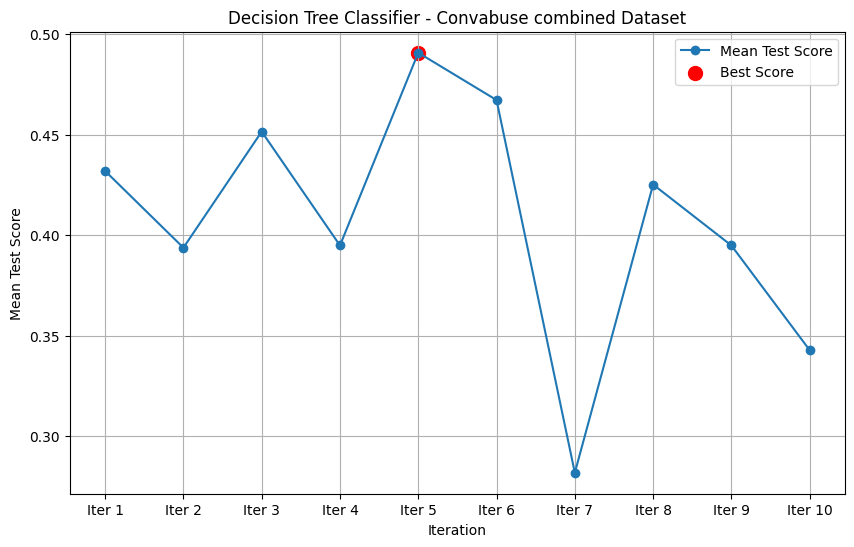

Convabuse combined Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.4348
F1 Score: 0.5258


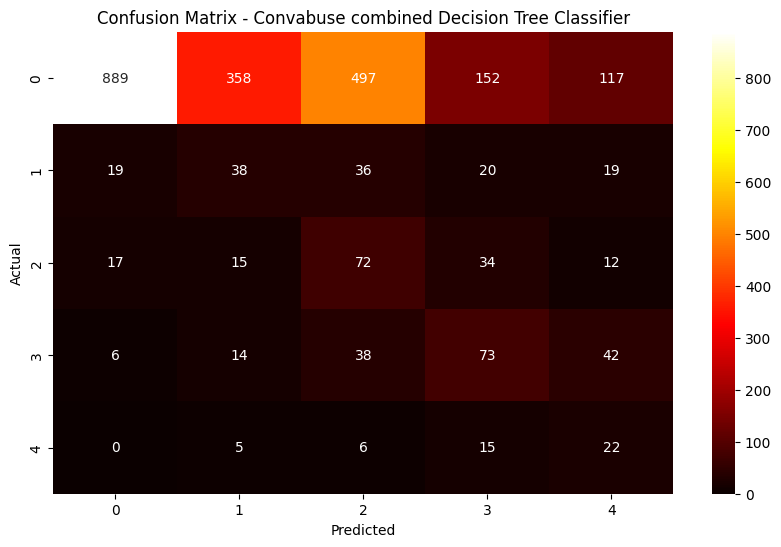

Classification Report for Convabuse combined Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.95      0.44      0.60      2013
           1       0.09      0.29      0.14       132
           2       0.11      0.48      0.18       150
           3       0.25      0.42      0.31       173
           4       0.10      0.46      0.17        48

    accuracy                           0.43      2516
   macro avg       0.30      0.42      0.28      2516
weighted avg       0.79      0.43      0.53      2516

Unsorted Feature Importances for Convabuse combined Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.007277945824937569), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.0), 8: np.float64(0.019962185250604694), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.020213279569849966), 15: n

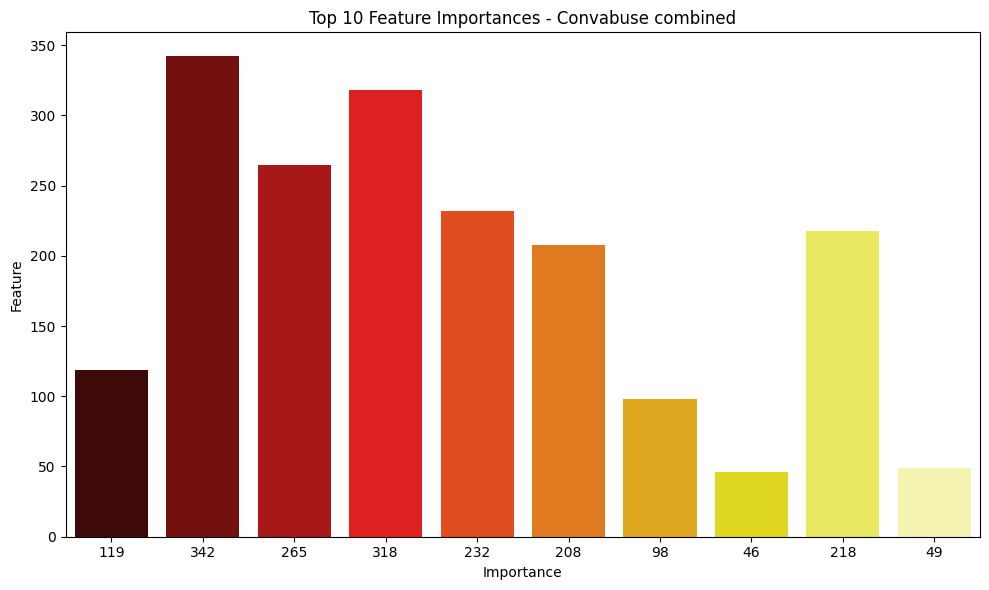

Top 10 Feature Importances for Convabuse combined Decision Tree Classifier:
{119: np.float64(0.02367372865258096), 342: np.float64(0.02918876377185936), 265: np.float64(0.03208951242751517), 318: np.float64(0.03456138891179955), 232: np.float64(0.036547568676818736), 208: np.float64(0.038435429645190373), 98: np.float64(0.04716023130164446), 46: np.float64(0.057559283994665714), 218: np.float64(0.09481180037523722), 49: np.float64(0.13109680408517502)}


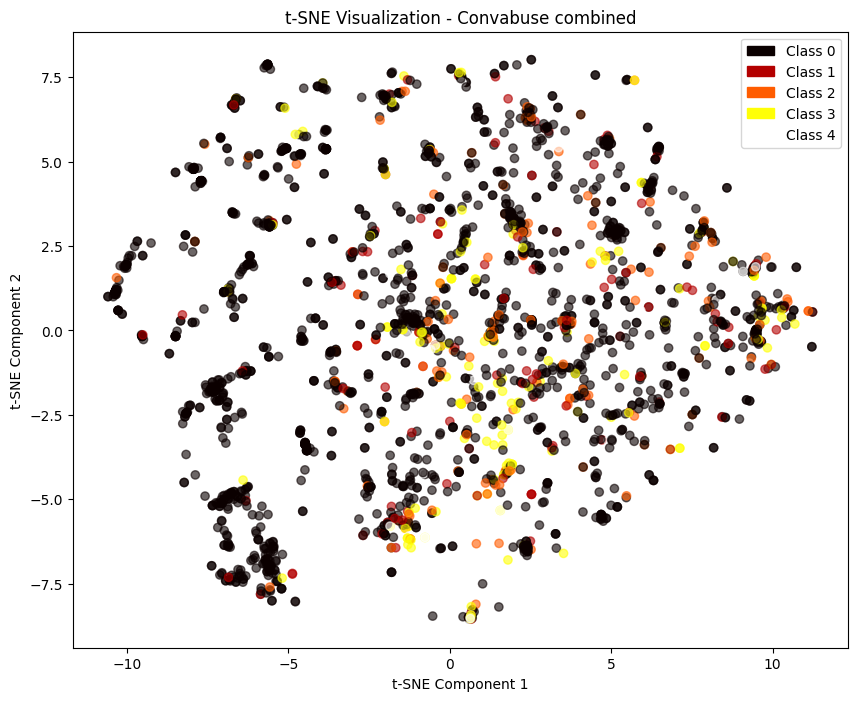

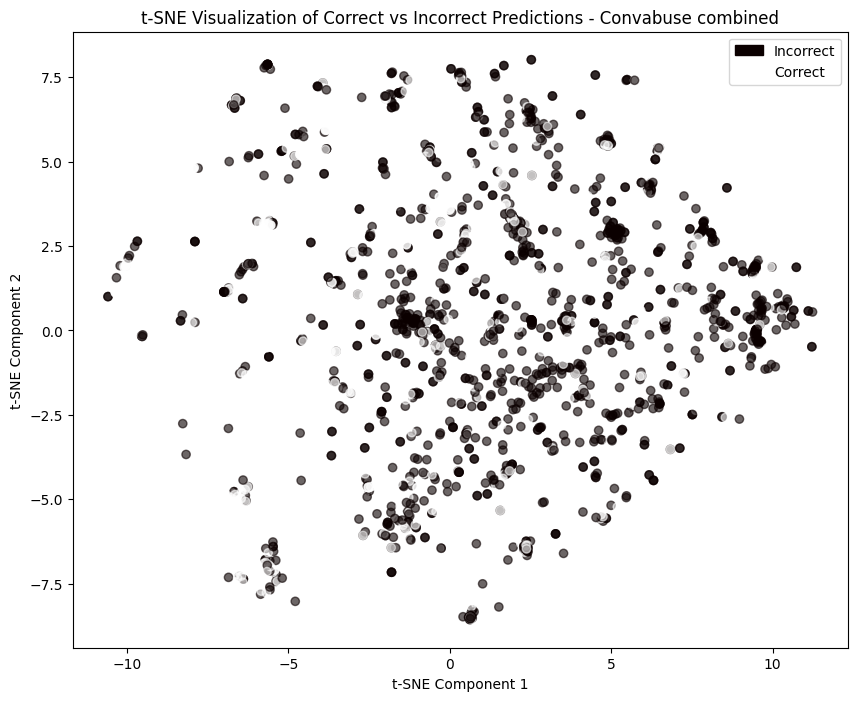

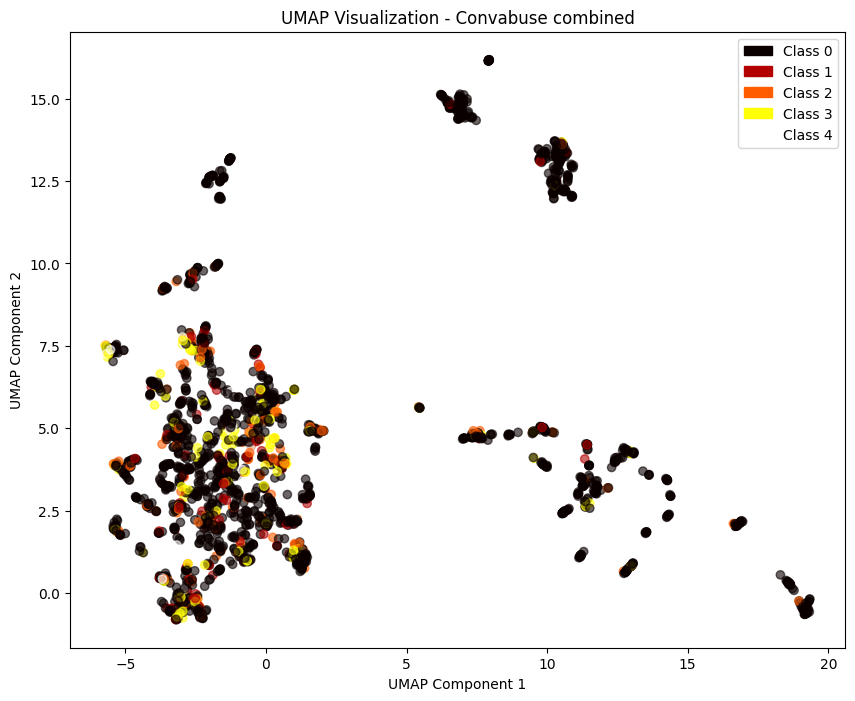

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.43481717011128773,
  0.5257649895408693,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.007277945824937569),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0),
   8: np.float64(0.019962185250604694),
   9: np.float64(0.0),
   10: np.float64(0.0),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.020213279569849966),
   15: np.float64(0.0),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.007319253120092025),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float64(0.0),
   27: np.float64(0.

In [23]:
dt_classifier_model(convabuse_X_train, convabuse_y_train, convabuse_X_test, convabuse_y_test, "Convabuse combined")
dt_classification_results_list

Best parameters for Convabuse prev_agent Decision Tree Classifier: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse prev_agent Decision Tree Classifier: 0.3274782608695652
Time taken for Convabuse prev_agent Decision Tree Classifier Randomized Search: 233.25831270217896


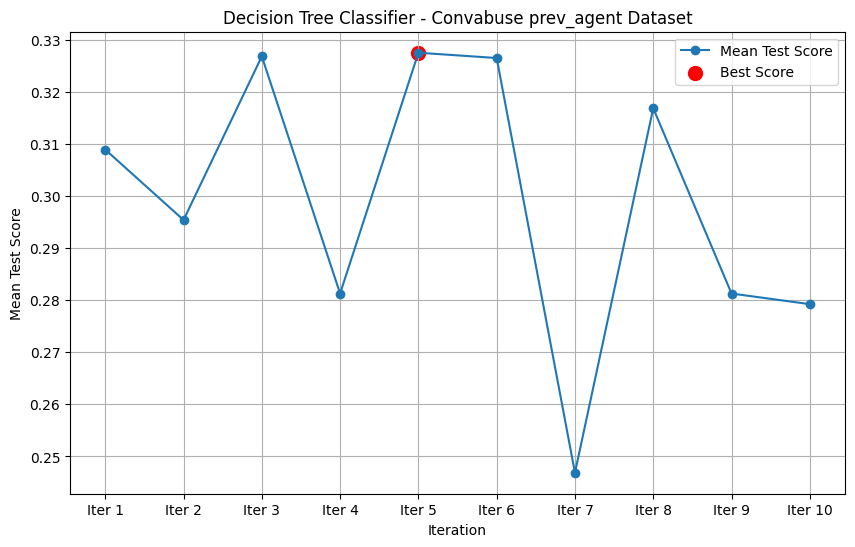

Convabuse prev_agent Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.3374
F1 Score: 0.4269


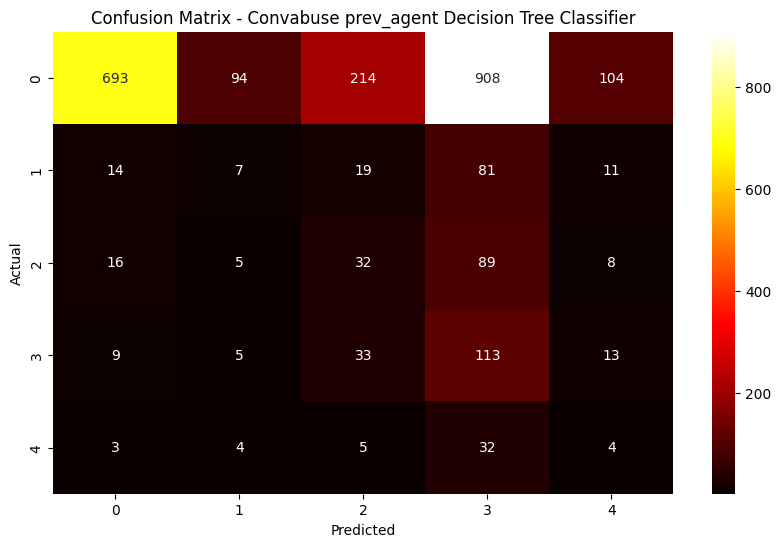

Classification Report for Convabuse prev_agent Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.94      0.34      0.50      2013
           1       0.06      0.05      0.06       132
           2       0.11      0.21      0.14       150
           3       0.09      0.65      0.16       173
           4       0.03      0.08      0.04        48

    accuracy                           0.34      2516
   macro avg       0.25      0.27      0.18      2516
weighted avg       0.77      0.34      0.43      2516

Unsorted Feature Importances for Convabuse prev_agent Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.0), 8: np.float64(0.03852451692661421), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.04111918564914797), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0),

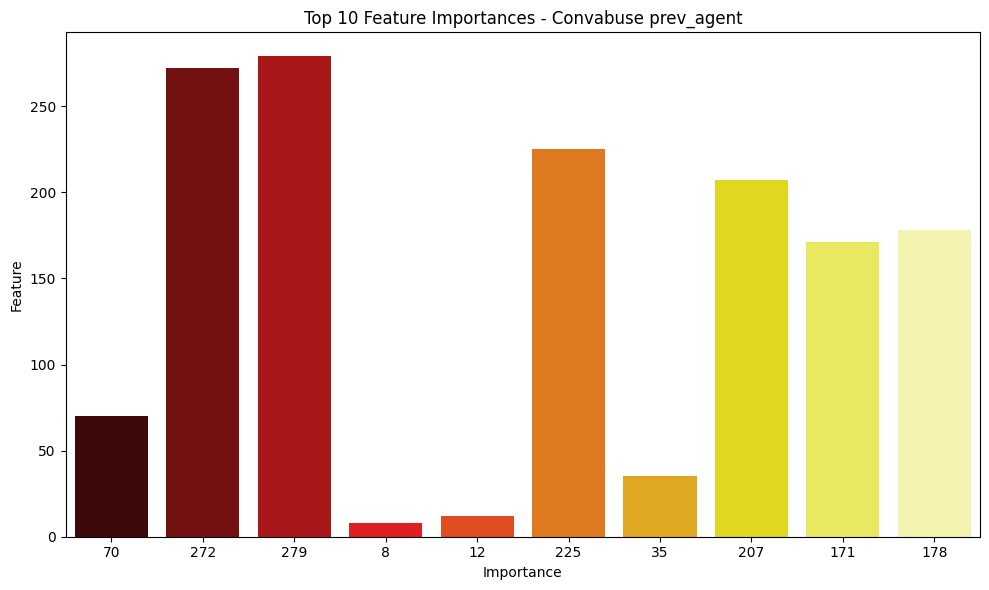

Top 10 Feature Importances for Convabuse prev_agent Decision Tree Classifier:
{70: np.float64(0.03197849873940117), 272: np.float64(0.03455924934612664), 279: np.float64(0.03840172801892028), 8: np.float64(0.03852451692661421), 12: np.float64(0.04111918564914797), 225: np.float64(0.04144928266707938), 35: np.float64(0.05679396012600425), 207: np.float64(0.06610272389279201), 171: np.float64(0.07299244236789065), 178: np.float64(0.2809612345122065)}


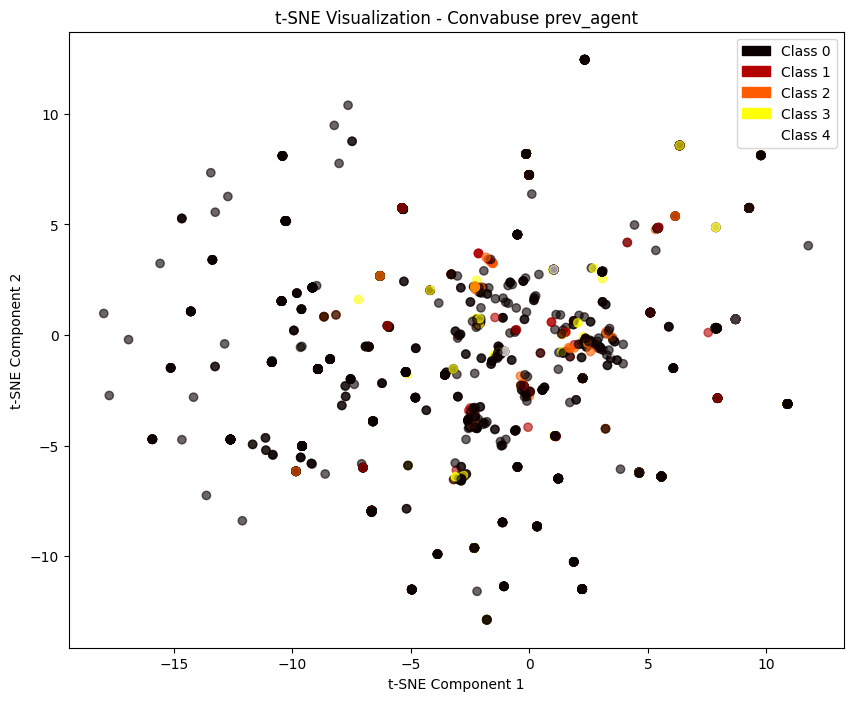

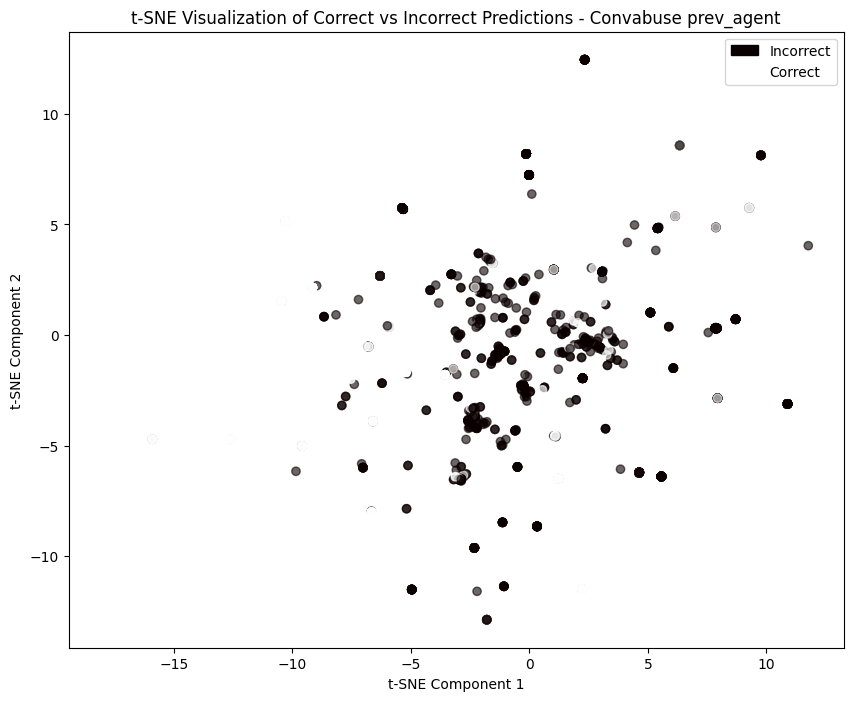

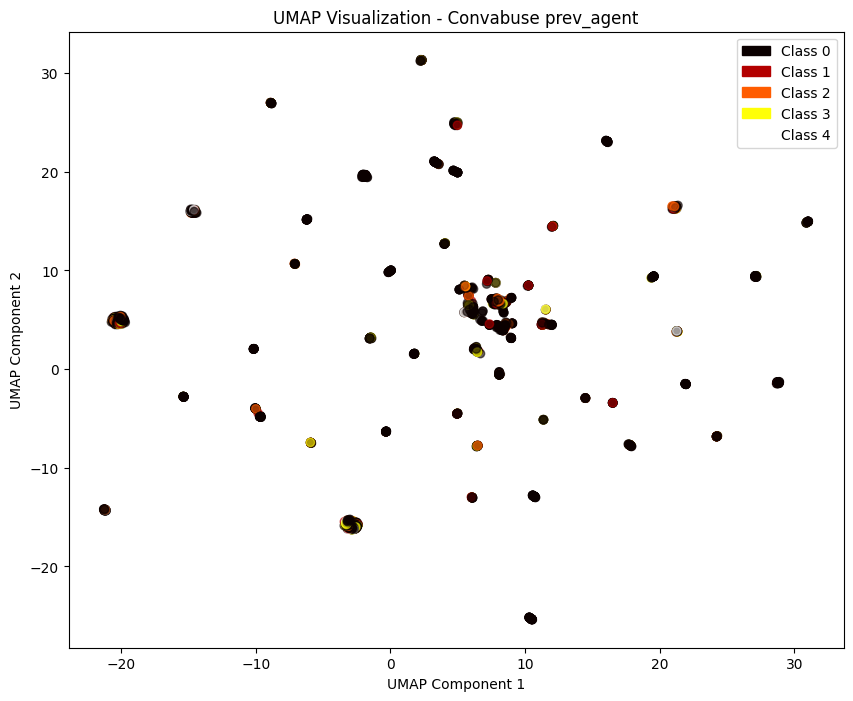

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.43481717011128773,
  0.5257649895408693,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.007277945824937569),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0),
   8: np.float64(0.019962185250604694),
   9: np.float64(0.0),
   10: np.float64(0.0),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.020213279569849966),
   15: np.float64(0.0),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.007319253120092025),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float64(0.0),
   27: np.float64(0.

In [24]:
dt_classifier_model(convabuse_prev_agent_X_train, convabuse_prev_agent_y_train, convabuse_prev_agent_X_test, convabuse_prev_agent_y_test, "Convabuse prev_agent")
dt_classification_results_list

Best parameters for Convabuse prev_user Decision Tree Classifier: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse prev_user Decision Tree Classifier: 0.397416149068323
Time taken for Convabuse prev_user Decision Tree Classifier Randomized Search: 541.9530146121979


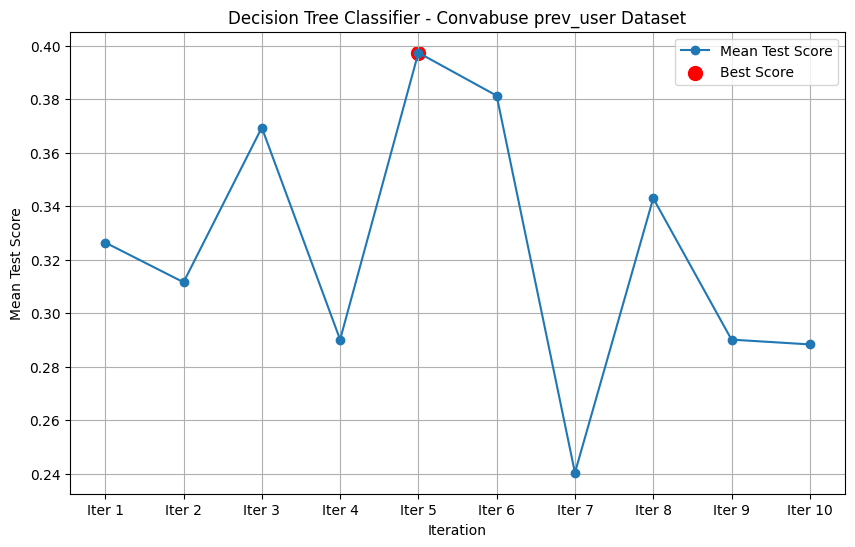

Convabuse prev_user Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.3565
F1 Score: 0.4518


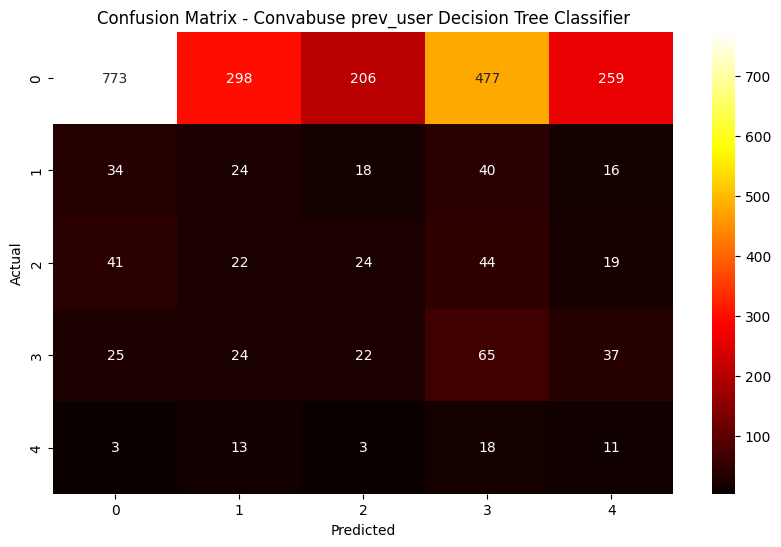

Classification Report for Convabuse prev_user Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.88      0.38      0.54      2013
           1       0.06      0.18      0.09       132
           2       0.09      0.16      0.11       150
           3       0.10      0.38      0.16       173
           4       0.03      0.23      0.06        48

    accuracy                           0.36      2516
   macro avg       0.23      0.27      0.19      2516
weighted avg       0.72      0.36      0.45      2516

Unsorted Feature Importances for Convabuse prev_user Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.015545036902712587), 6: np.float64(0.0), 7: np.float64(0.0), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0

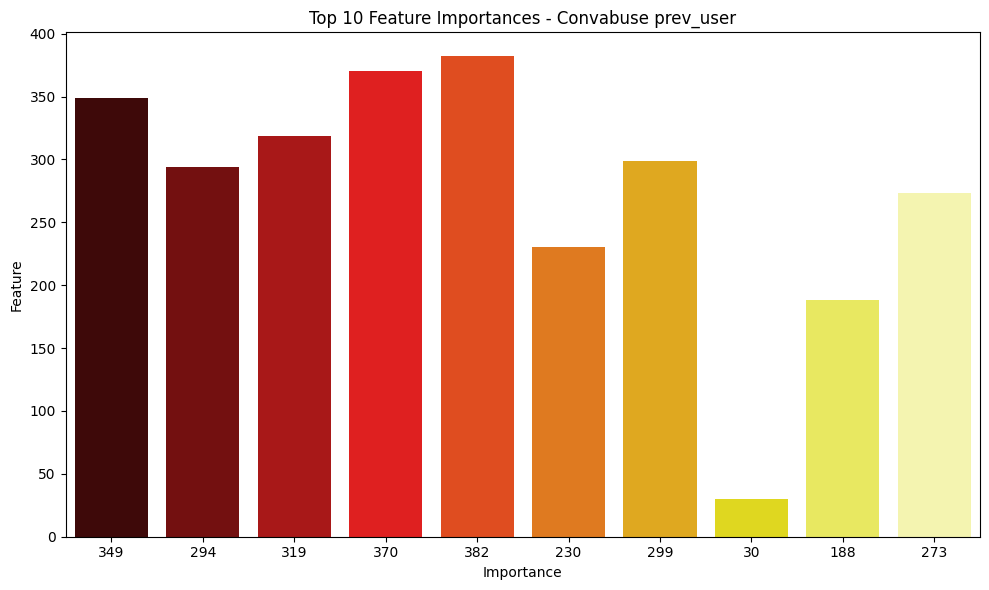

Top 10 Feature Importances for Convabuse prev_user Decision Tree Classifier:
{349: np.float64(0.028410585615974083), 294: np.float64(0.028663663617678636), 319: np.float64(0.03339388606199916), 370: np.float64(0.036523435274754684), 382: np.float64(0.03886741541234863), 230: np.float64(0.04057104587130504), 299: np.float64(0.04389708254497773), 30: np.float64(0.045670484774126566), 188: np.float64(0.04933879572588299), 273: np.float64(0.06574735694266334)}


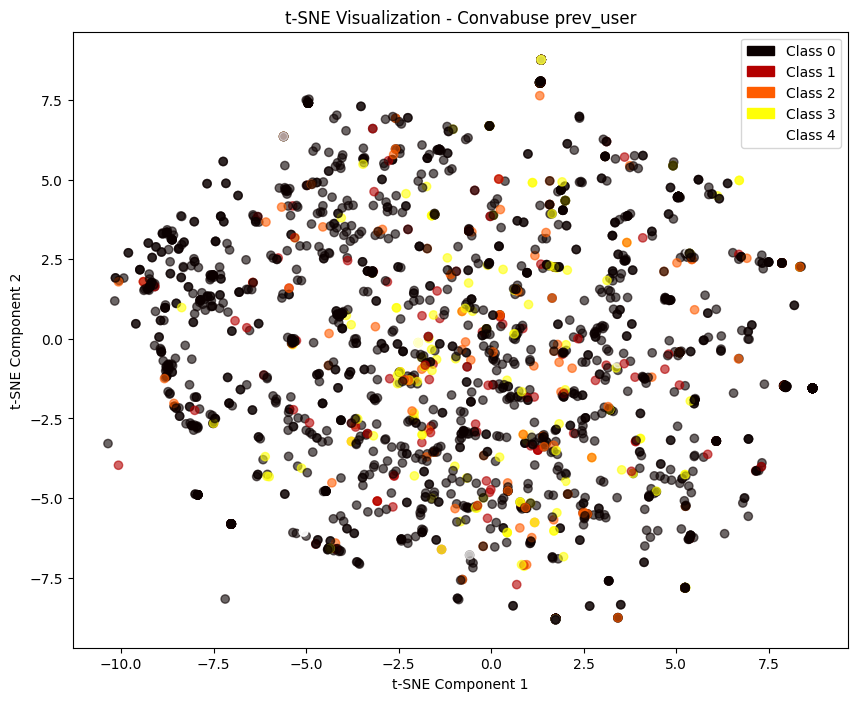

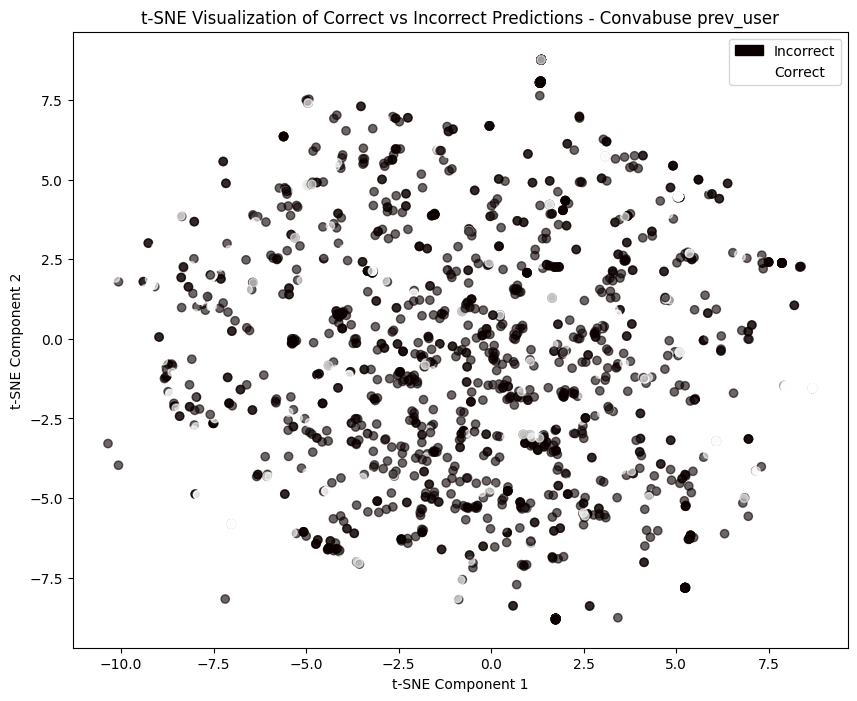

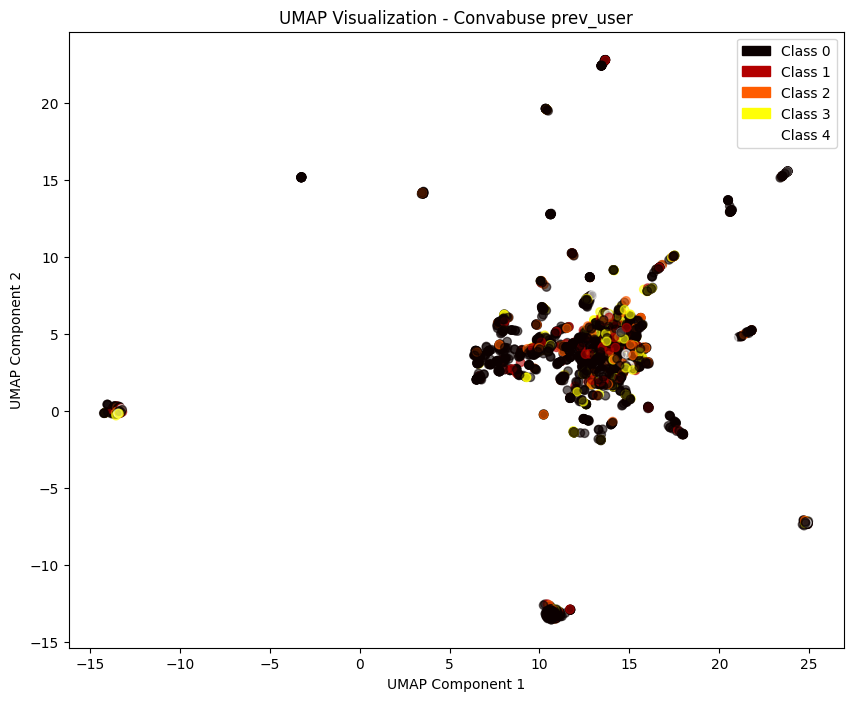

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.43481717011128773,
  0.5257649895408693,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.007277945824937569),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0),
   8: np.float64(0.019962185250604694),
   9: np.float64(0.0),
   10: np.float64(0.0),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.020213279569849966),
   15: np.float64(0.0),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.007319253120092025),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float64(0.0),
   27: np.float64(0.

In [25]:
dt_classifier_model(convabuse_prev_user_X_train, convabuse_prev_user_y_train, convabuse_prev_user_X_test, convabuse_prev_user_y_test, "Convabuse prev_user")
dt_classification_results_list

Best parameters for Convabuse agent Decision Tree Classifier: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse agent Decision Tree Classifier: 0.37013664596273294
Time taken for Convabuse agent Decision Tree Classifier Randomized Search: 221.36371183395386


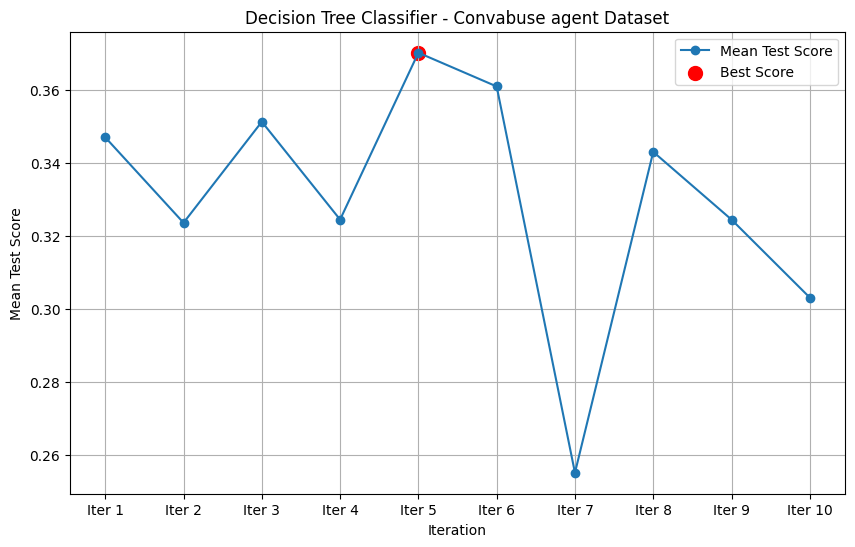

Convabuse agent Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.3315
F1 Score: 0.4367


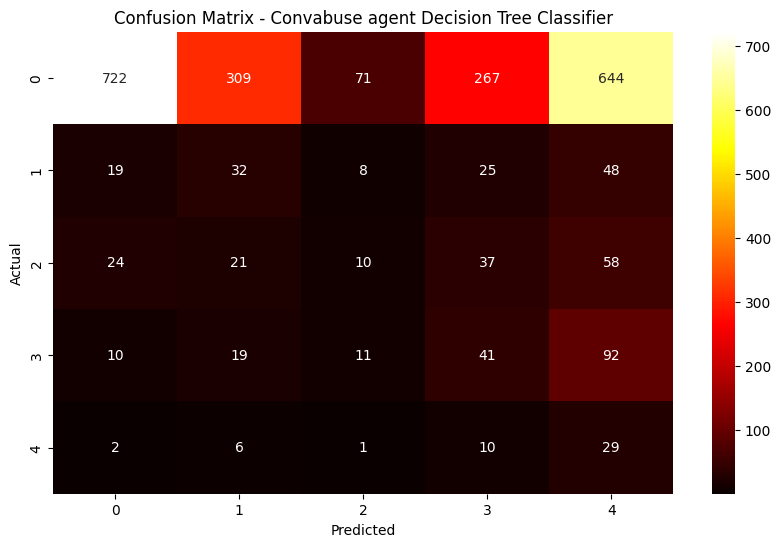

Classification Report for Convabuse agent Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.93      0.36      0.52      2013
           1       0.08      0.24      0.12       132
           2       0.10      0.07      0.08       150
           3       0.11      0.24      0.15       173
           4       0.03      0.60      0.06        48

    accuracy                           0.33      2516
   macro avg       0.25      0.30      0.19      2516
weighted avg       0.76      0.33      0.44      2516

Unsorted Feature Importances for Convabuse agent Decision Tree Classifier:
{0: np.float64(0.010725698468945093), 1: np.float64(0.0412632805764356), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.0025631715346123), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.03115684493252797),

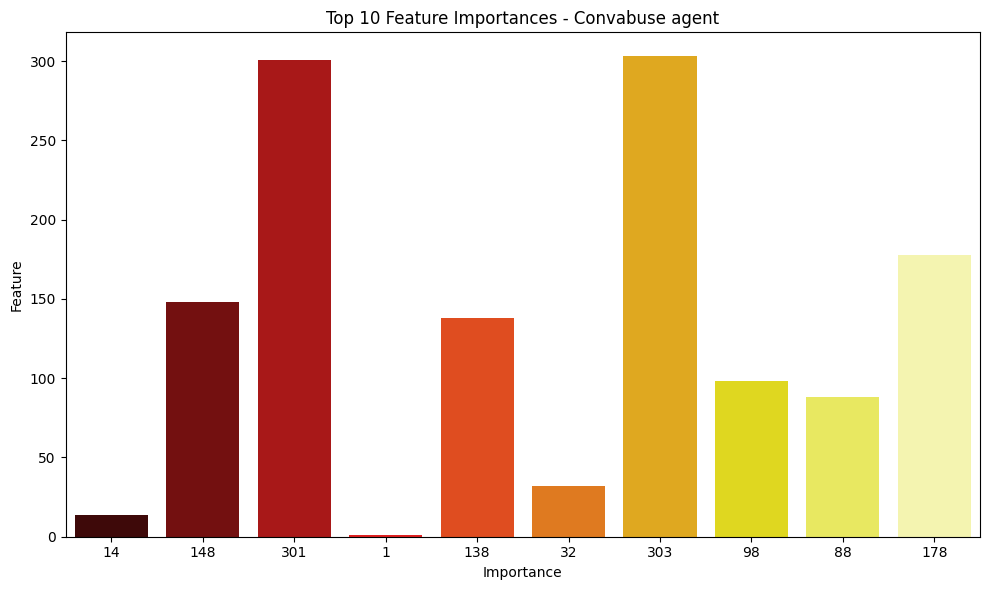

Top 10 Feature Importances for Convabuse agent Decision Tree Classifier:
{14: np.float64(0.03115684493252797), 148: np.float64(0.033820609982797845), 301: np.float64(0.03692485650901471), 1: np.float64(0.0412632805764356), 138: np.float64(0.04203623384185515), 32: np.float64(0.04865195766752447), 303: np.float64(0.05323742269764628), 98: np.float64(0.06466109821310742), 88: np.float64(0.08555288920159734), 178: np.float64(0.2871696418163336)}


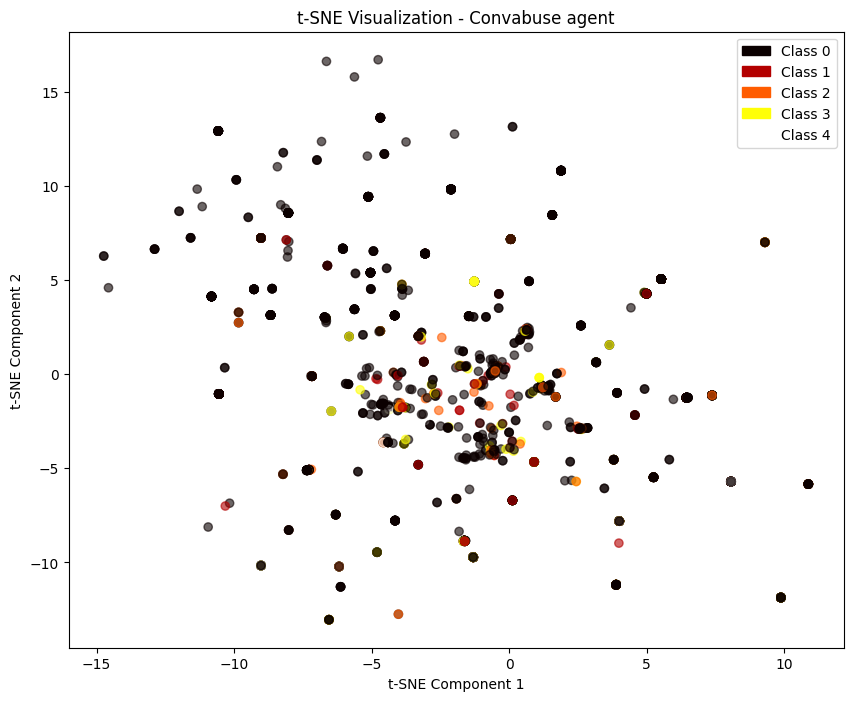

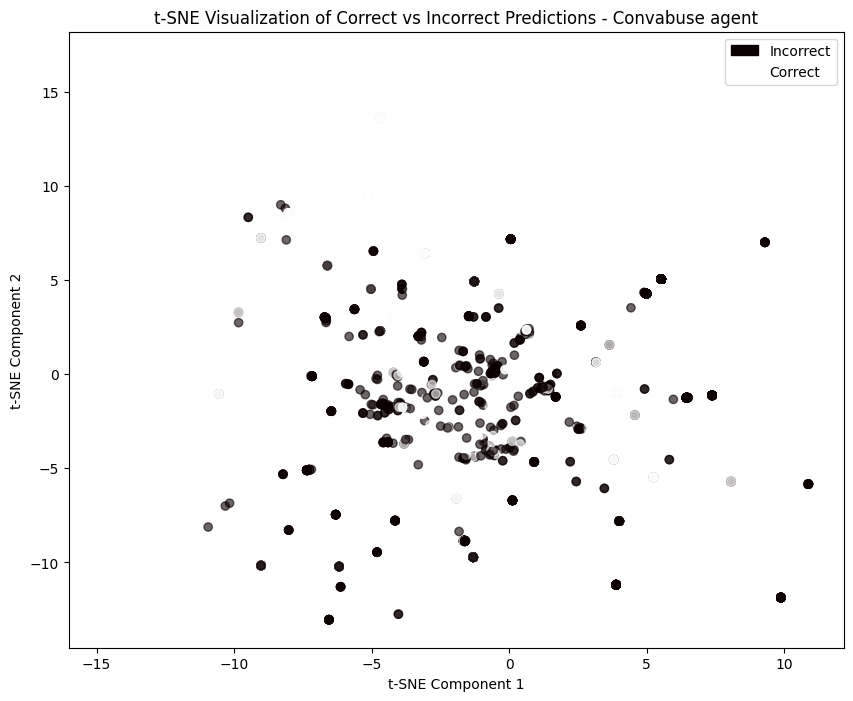

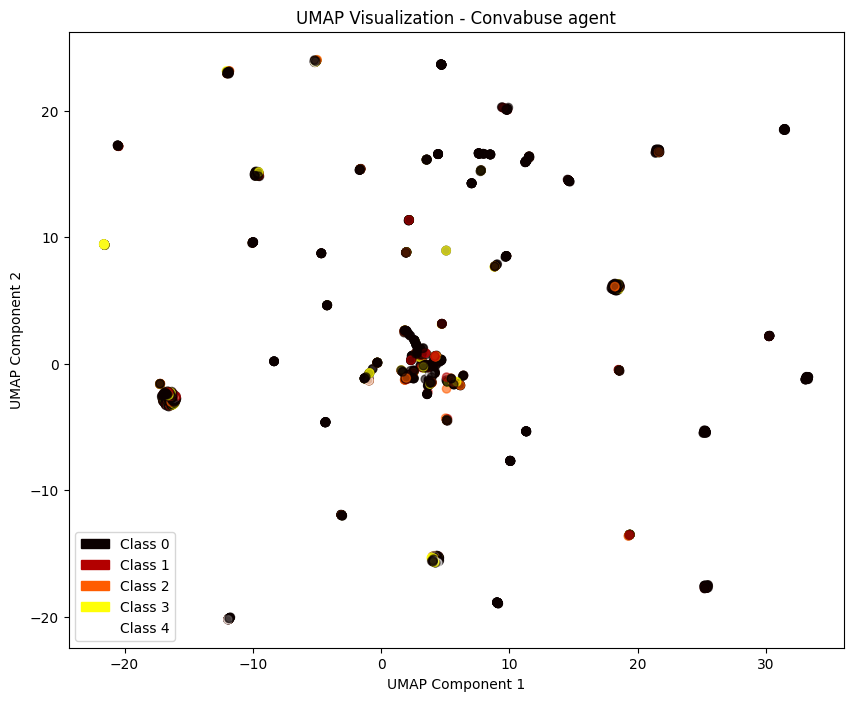

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.43481717011128773,
  0.5257649895408693,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.007277945824937569),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0),
   8: np.float64(0.019962185250604694),
   9: np.float64(0.0),
   10: np.float64(0.0),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.020213279569849966),
   15: np.float64(0.0),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.007319253120092025),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float64(0.0),
   27: np.float64(0.

In [26]:
dt_classifier_model(convabuse_agent_X_train, convabuse_agent_y_train, convabuse_agent_X_test, convabuse_agent_y_test, "Convabuse agent")
dt_classification_results_list

Best parameters for Convabuse user Decision Tree Classifier: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Best score for Convabuse user Decision Tree Classifier: 0.5413167701863355
Time taken for Convabuse user Decision Tree Classifier Randomized Search: 487.4588568210602


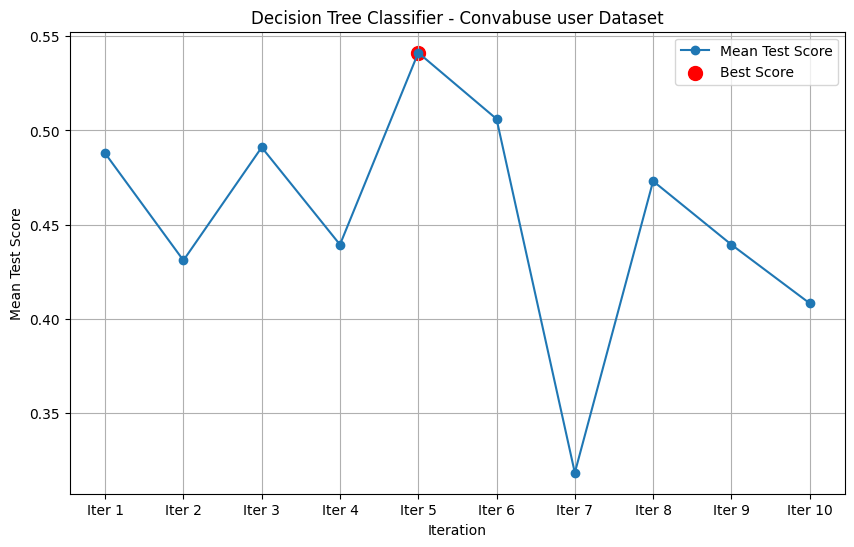

Convabuse user Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1209, 'dt_classifier__min_samples_leaf': 403, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.4742
F1 Score: 0.5693


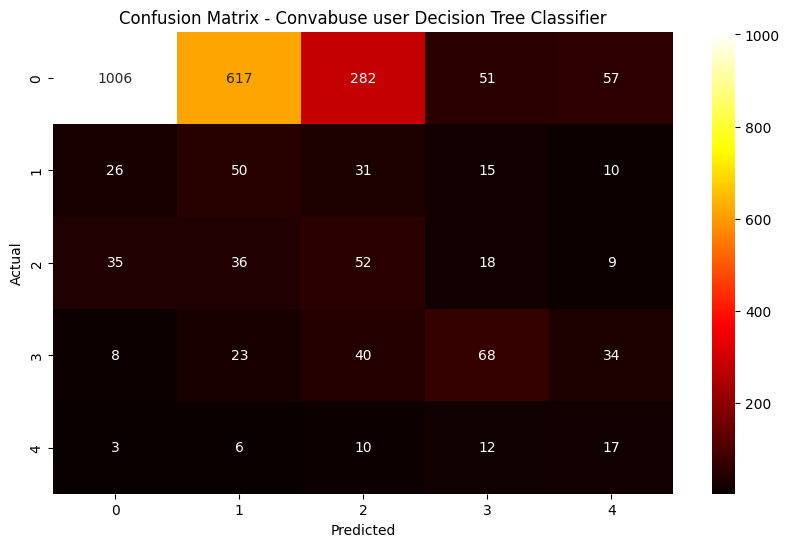

Classification Report for Convabuse user Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.93      0.50      0.65      2013
           1       0.07      0.38      0.12       132
           2       0.13      0.35      0.18       150
           3       0.41      0.39      0.40       173
           4       0.13      0.35      0.19        48

    accuracy                           0.47      2516
   macro avg       0.34      0.39      0.31      2516
weighted avg       0.79      0.47      0.57      2516

Unsorted Feature Importances for Convabuse user Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.007302260307335175), 7: np.float64(0.0), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.01849524587772071), 15: np.float64(0.0), 16: np.flo

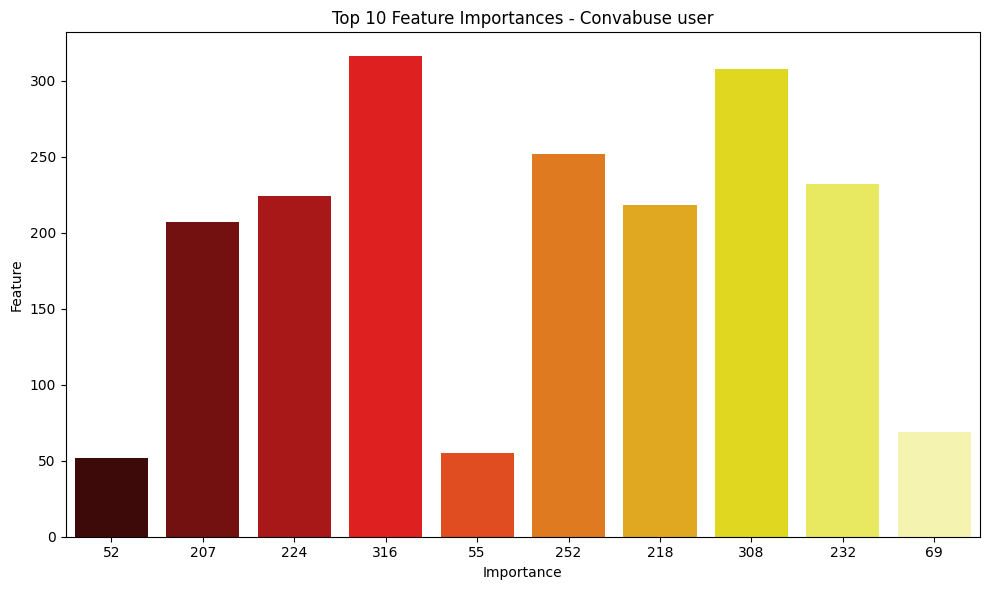

Top 10 Feature Importances for Convabuse user Decision Tree Classifier:
{52: np.float64(0.02651014800499396), 207: np.float64(0.028353320668703136), 224: np.float64(0.030618328237297748), 316: np.float64(0.031428531665423316), 55: np.float64(0.03231490224728541), 252: np.float64(0.047817162329943666), 218: np.float64(0.05429145091489326), 308: np.float64(0.06096217500507998), 232: np.float64(0.10394498895070593), 69: np.float64(0.1916026860164045)}


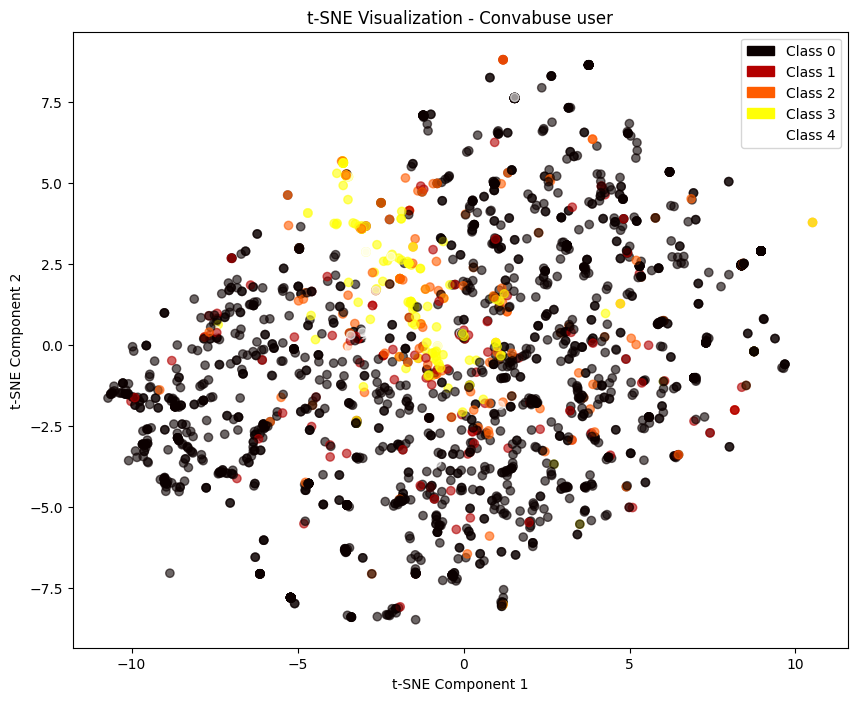

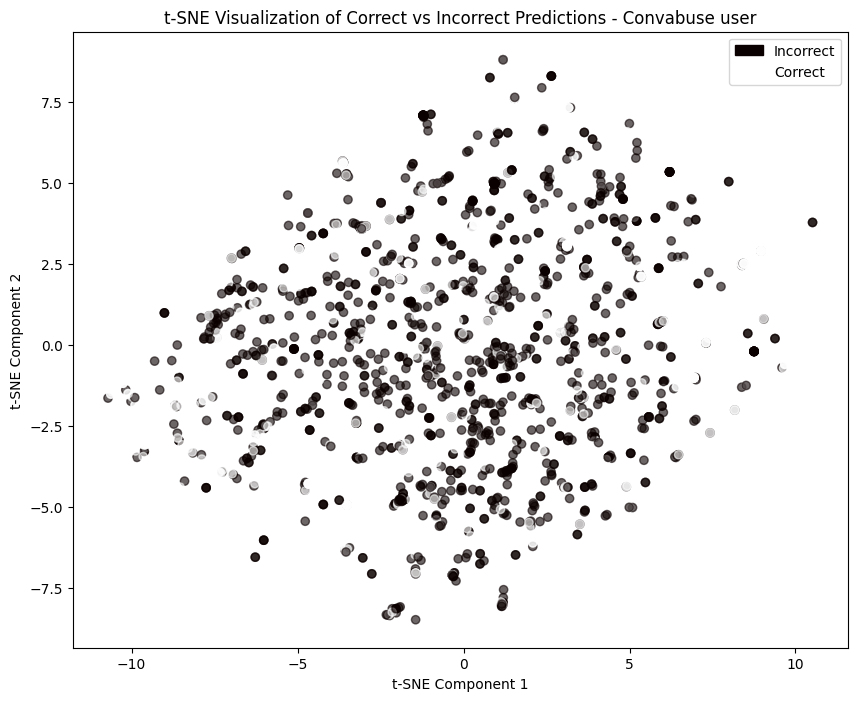

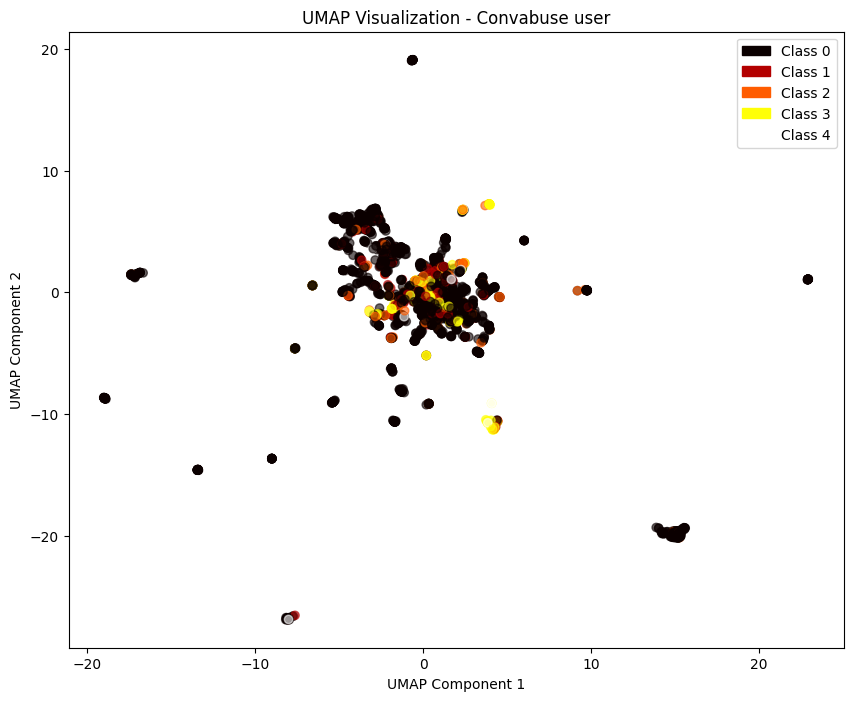

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.43481717011128773,
  0.5257649895408693,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.007277945824937569),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0),
   8: np.float64(0.019962185250604694),
   9: np.float64(0.0),
   10: np.float64(0.0),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.020213279569849966),
   15: np.float64(0.0),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.007319253120092025),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float64(0.0),
   27: np.float64(0.

In [27]:
dt_classifier_model(convabuse_user_X_train, convabuse_user_y_train, convabuse_user_X_test, convabuse_user_y_test, "Convabuse user")
dt_classification_results_list

## Dynamically Generated Hate Speech Decision Tree

Best parameters for Dynamically Generated Hate Speech target Decision Tree Classifier: {'dt_classifier__min_samples_split': 1488, 'dt_classifier__min_samples_leaf': 496, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Best score for Dynamically Generated Hate Speech target Decision Tree Classifier: 0.6501190817746931
Time taken for Dynamically Generated Hate Speech target Decision Tree Classifier Randomized Search: 821.9396119117737


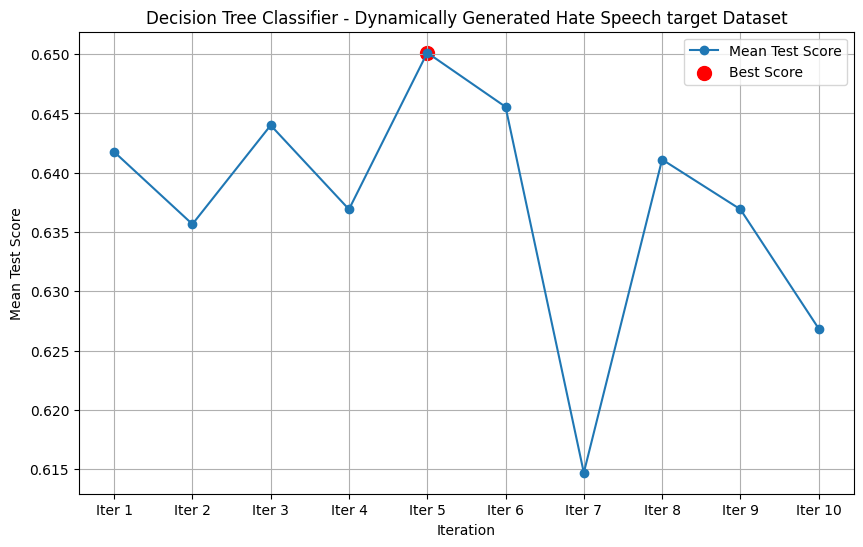

Dynamically Generated Hate Speech target Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1488, 'dt_classifier__min_samples_leaf': 496, 'dt_classifier__max_depth': 10, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.6168
F1 Score: 0.6436


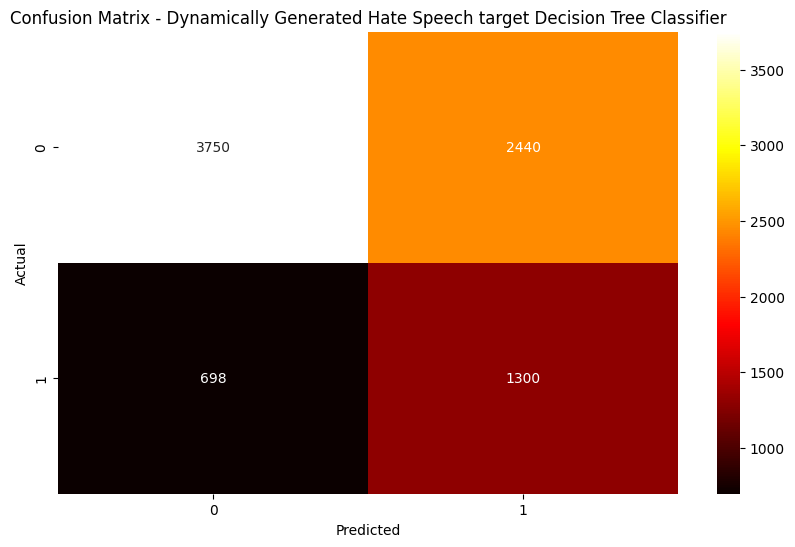

Classification Report for Dynamically Generated Hate Speech target Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.84      0.61      0.71      6190
           1       0.35      0.65      0.45      1998

    accuracy                           0.62      8188
   macro avg       0.60      0.63      0.58      8188
weighted avg       0.72      0.62      0.64      8188

Unsorted Feature Importances for Dynamically Generated Hate Speech target Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.02661328684297014), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0.0), 17: np.float64(0.0), 18: np.float64(0.0), 19: np.float64(0.0), 20: np.float64(0.0), 21: np.float64(0.0), 22: np.floa

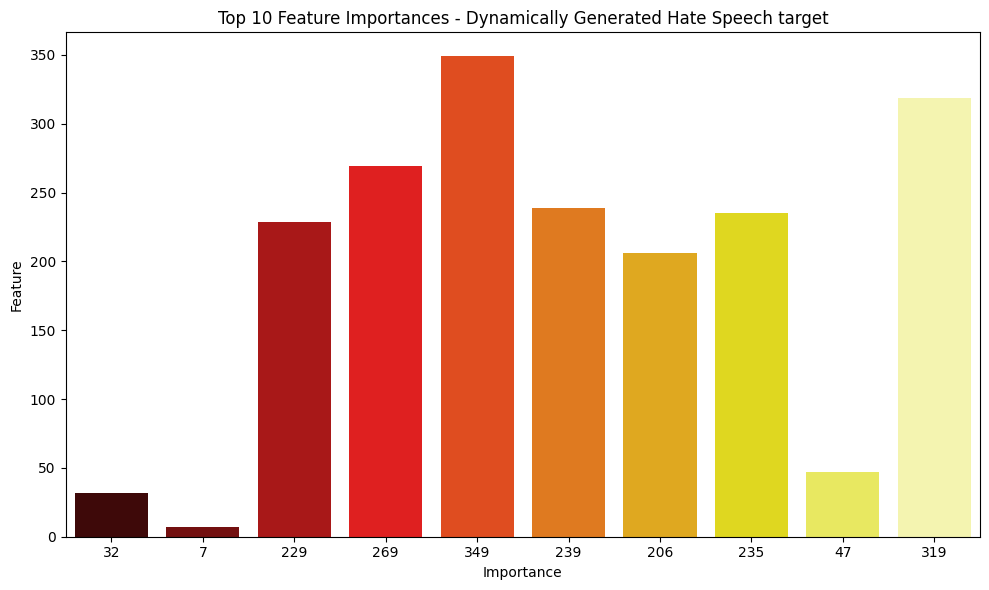

Top 10 Feature Importances for Dynamically Generated Hate Speech target Decision Tree Classifier:
{32: np.float64(0.019649523102146804), 7: np.float64(0.02661328684297014), 229: np.float64(0.029112680199437774), 269: np.float64(0.03492517495639628), 349: np.float64(0.03684829041200086), 239: np.float64(0.04180271974179016), 206: np.float64(0.043823135708532565), 235: np.float64(0.045464667705548974), 47: np.float64(0.061554179626222665), 319: np.float64(0.4817641514940098)}


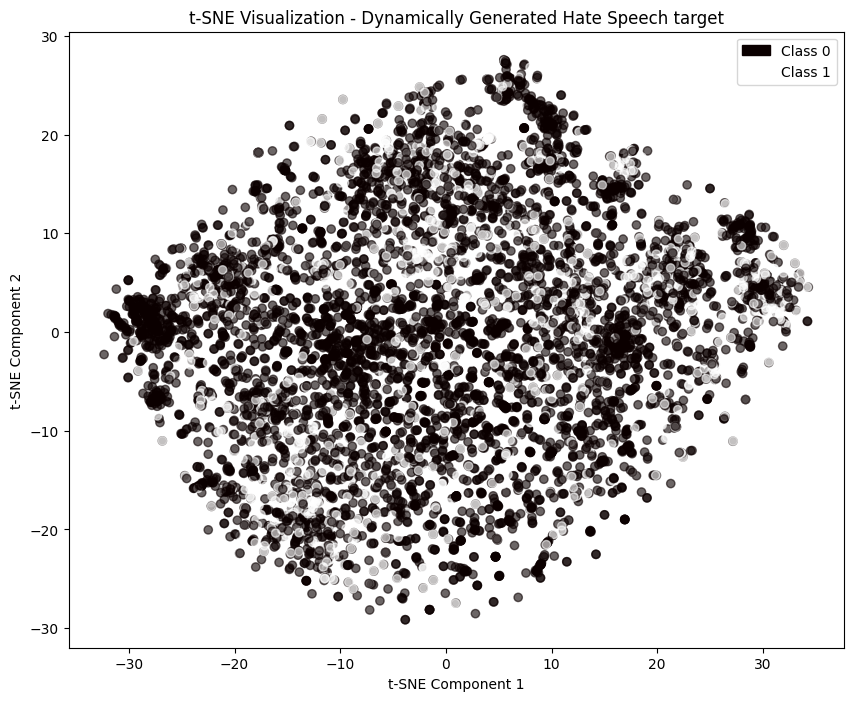

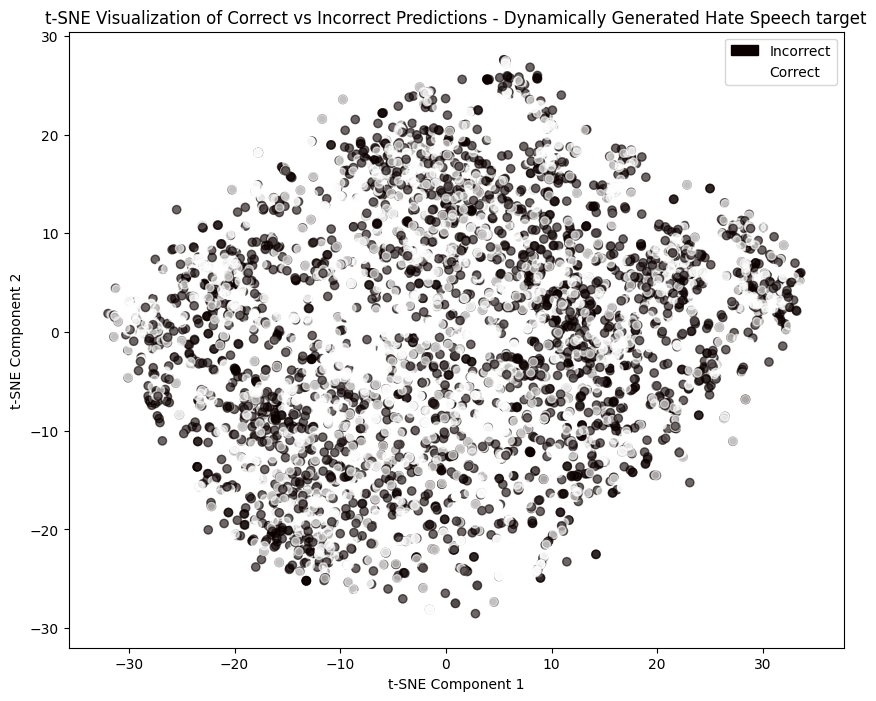

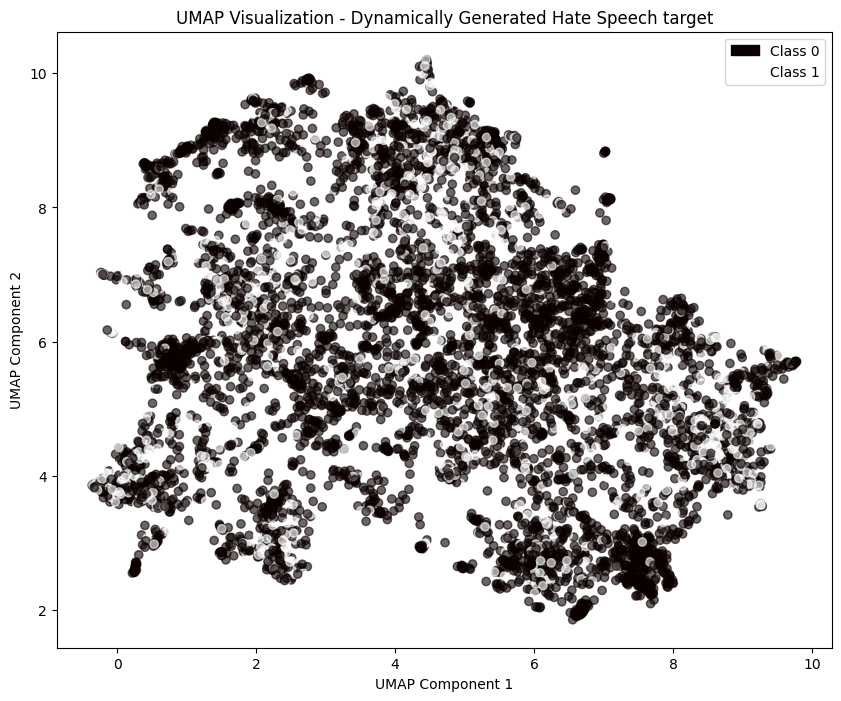

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.43481717011128773,
  0.5257649895408693,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.007277945824937569),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0),
   8: np.float64(0.019962185250604694),
   9: np.float64(0.0),
   10: np.float64(0.0),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.020213279569849966),
   15: np.float64(0.0),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.007319253120092025),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float64(0.0),
   27: np.float64(0.

In [28]:
dt_classifier_model(dynamically_generated_hate_speech_target_X_train, dynamically_generated_hate_speech_target_y_train, dynamically_generated_hate_speech_target_X_test, dynamically_generated_hate_speech_target_y_test, "Dynamically Generated Hate Speech target")
dt_classification_results_list

Best parameters for Dynamically Generated Hate Speech label Decision Tree Classifier: {'dt_classifier__min_samples_split': 1056, 'dt_classifier__min_samples_leaf': 704, 'dt_classifier__max_depth': 14, 'dt_classifier__criterion': 'entropy'}
Best score for Dynamically Generated Hate Speech label Decision Tree Classifier: 0.6092526733890706
Time taken for Dynamically Generated Hate Speech label Decision Tree Classifier Randomized Search: 529.1812634468079


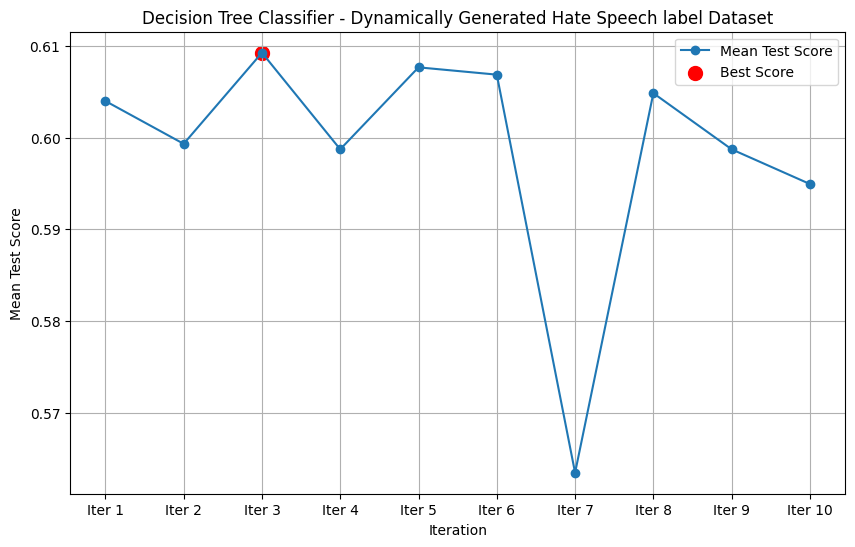

Dynamically Generated Hate Speech label Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 1056, 'dt_classifier__min_samples_leaf': 704, 'dt_classifier__max_depth': 14, 'dt_classifier__criterion': 'entropy'}
Accuracy: 0.6164
F1 Score: 0.6169


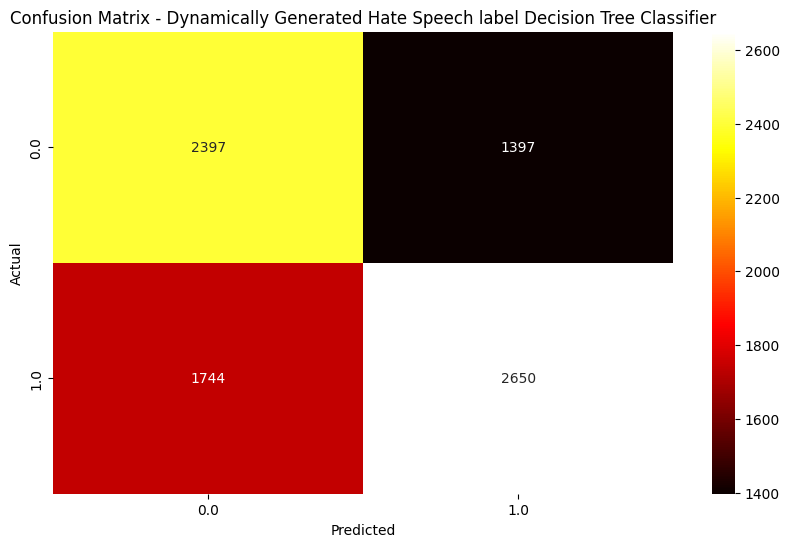

Classification Report for Dynamically Generated Hate Speech label Decision Tree Classifier:
              precision    recall  f1-score   support

         0.0       0.58      0.63      0.60      3794
         1.0       0.65      0.60      0.63      4394

    accuracy                           0.62      8188
   macro avg       0.62      0.62      0.62      8188
weighted avg       0.62      0.62      0.62      8188

Unsorted Feature Importances for Dynamically Generated Hate Speech label Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.0), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.0), 7: np.float64(0.10673851806366703), 8: np.float64(0.0), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0.0), 17: np.float64(0.0), 18: np.float64(0.0), 19: np.float64(0.0), 20: np.float64(0.0), 21: np.float64(0.0), 22: np.float6

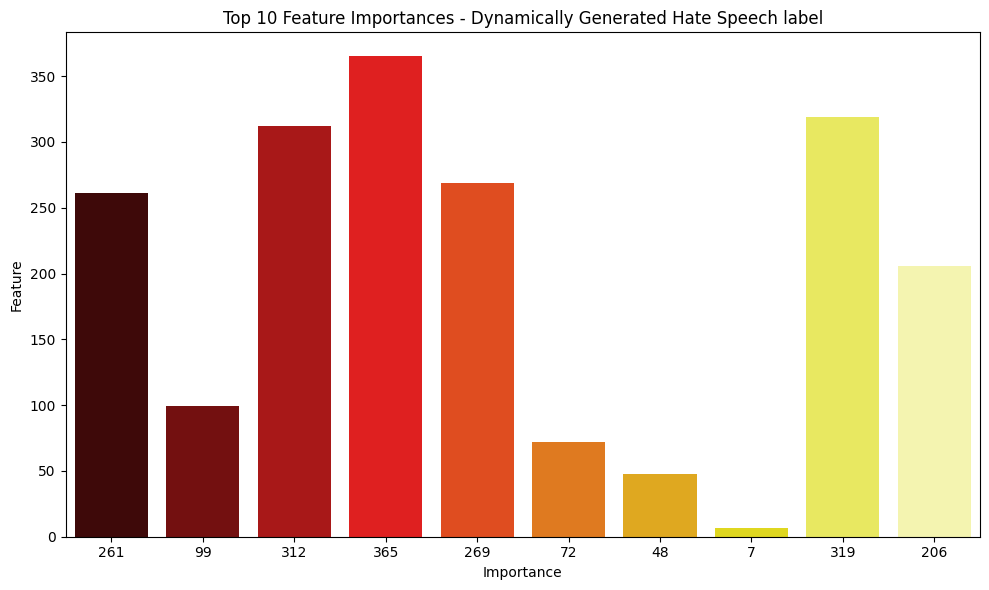

Top 10 Feature Importances for Dynamically Generated Hate Speech label Decision Tree Classifier:
{261: np.float64(0.025914915854471525), 99: np.float64(0.026900217847965004), 312: np.float64(0.04872119165893643), 365: np.float64(0.06457511854583896), 269: np.float64(0.0709871948455254), 72: np.float64(0.08454312490415733), 48: np.float64(0.08568147867157533), 7: np.float64(0.10673851806366703), 319: np.float64(0.10814474849921485), 206: np.float64(0.2082418810480231)}


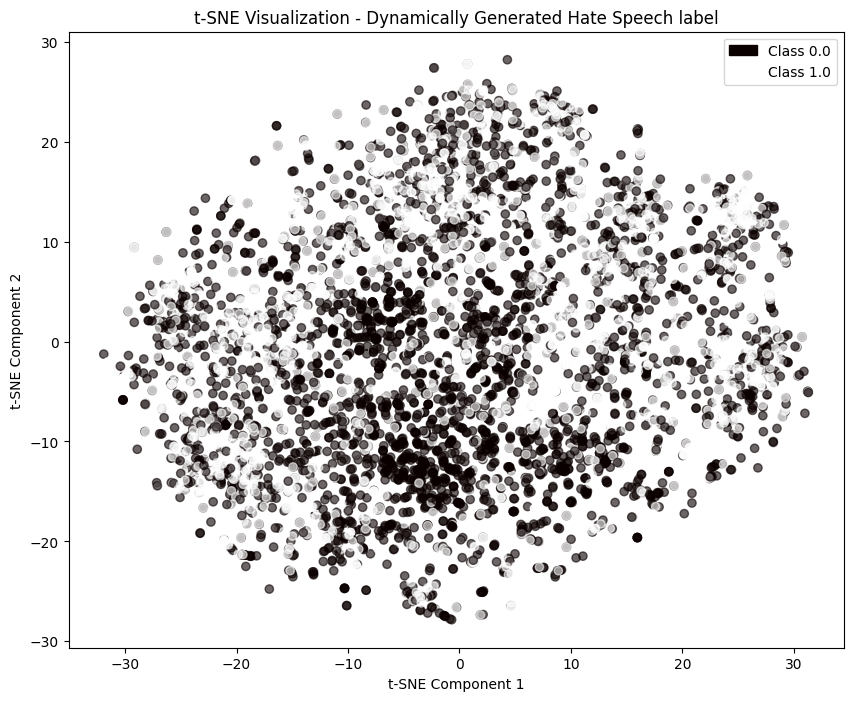

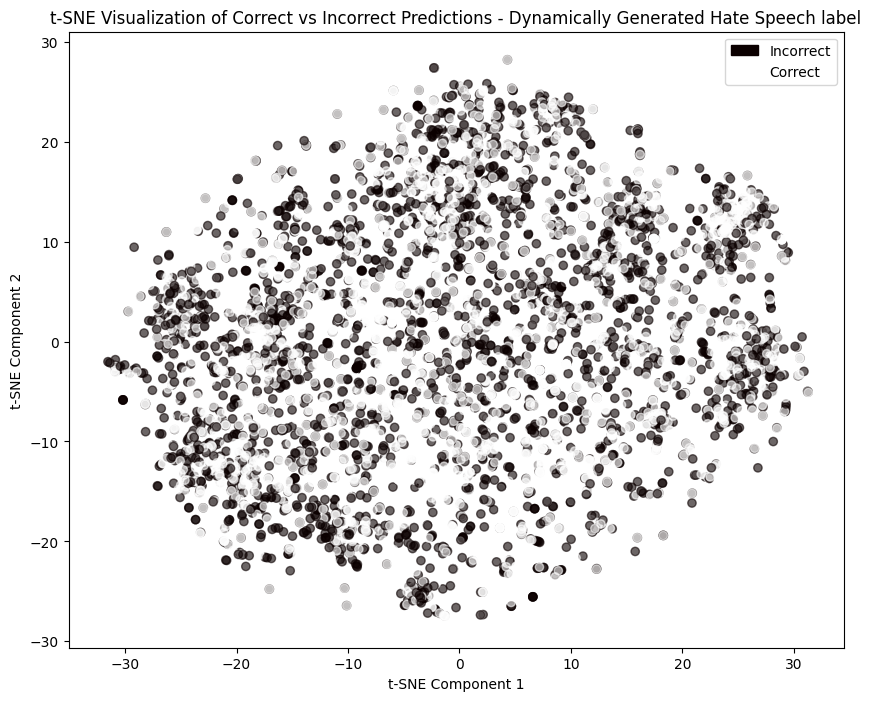

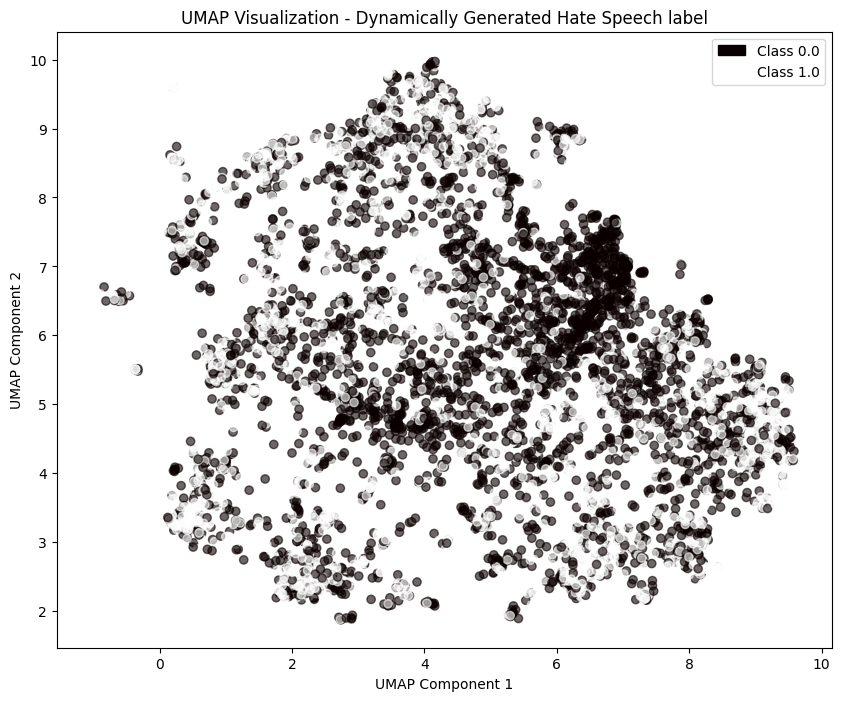

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.43481717011128773,
  0.5257649895408693,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.007277945824937569),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0),
   8: np.float64(0.019962185250604694),
   9: np.float64(0.0),
   10: np.float64(0.0),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.020213279569849966),
   15: np.float64(0.0),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.007319253120092025),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float64(0.0),
   27: np.float64(0.

In [29]:
dt_classifier_model(dynamically_generated_hate_speech_label_X_train, dynamically_generated_hate_speech_label_y_train, dynamically_generated_hate_speech_label_X_test, dynamically_generated_hate_speech_label_y_test, "Dynamically Generated Hate Speech label")
dt_classification_results_list

## MLMA Hate Speech Decision Tree

Best parameters for MLMA Hate Speech Decision Tree Classifier: {'dt_classifier__min_samples_split': 490, 'dt_classifier__min_samples_leaf': 245, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Best score for MLMA Hate Speech Decision Tree Classifier: 0.5264922322158626
Time taken for MLMA Hate Speech Decision Tree Classifier Randomized Search: 381.0277569293976


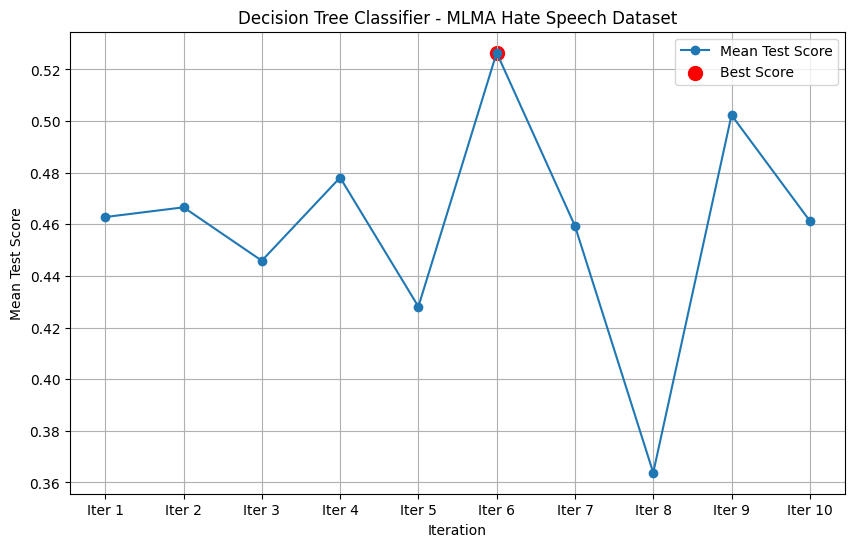

MLMA Hate Speech Decision Tree Classifier:
Best Parameters: {'dt_classifier__min_samples_split': 490, 'dt_classifier__min_samples_leaf': 245, 'dt_classifier__max_depth': 8, 'dt_classifier__criterion': 'gini'}
Accuracy: 0.3515
F1 Score: 0.4011


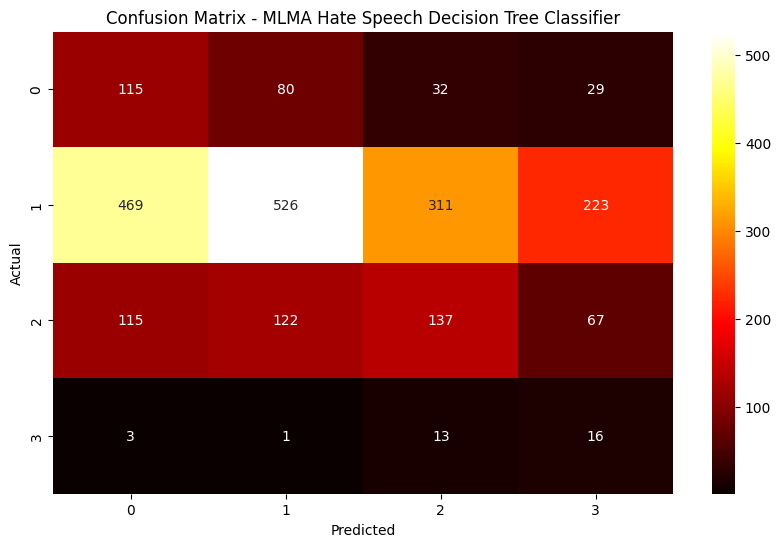

Classification Report for MLMA Hate Speech Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.16      0.45      0.24       256
           1       0.72      0.34      0.47      1529
           2       0.28      0.31      0.29       441
           3       0.05      0.48      0.09        33

    accuracy                           0.35      2259
   macro avg       0.30      0.40      0.27      2259
weighted avg       0.56      0.35      0.40      2259

Unsorted Feature Importances for MLMA Hate Speech Decision Tree Classifier:
{0: np.float64(0.0), 1: np.float64(0.010927005111364583), 2: np.float64(0.0), 3: np.float64(0.0), 4: np.float64(0.0), 5: np.float64(0.0), 6: np.float64(0.014130330984064207), 7: np.float64(0.0), 8: np.float64(0.0004514285425767724), 9: np.float64(0.0), 10: np.float64(0.0), 11: np.float64(0.0), 12: np.float64(0.0), 13: np.float64(0.0), 14: np.float64(0.0), 15: np.float64(0.0), 16: np.float64(0.0), 17: np.float64(0.0),

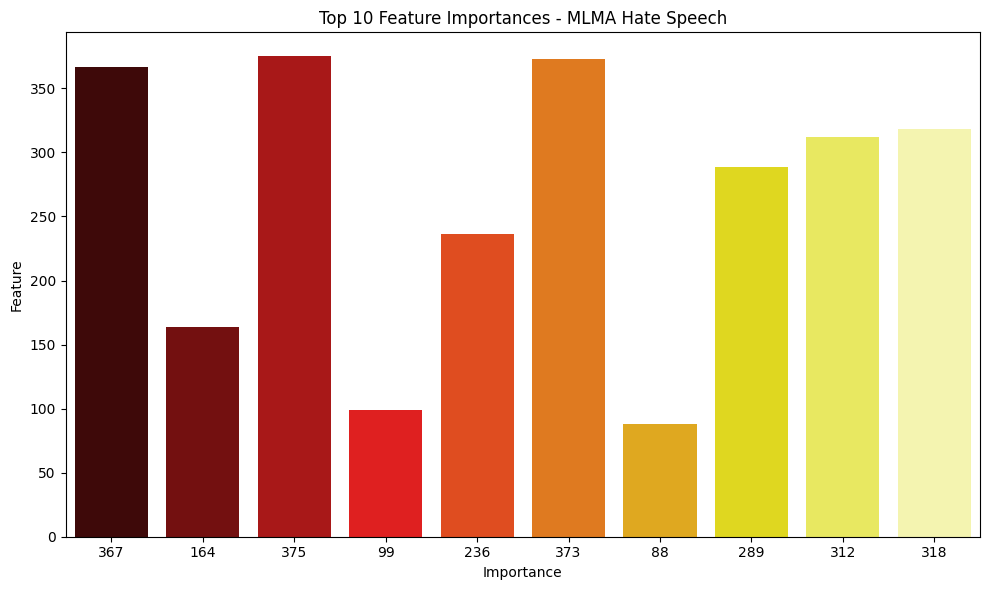

Top 10 Feature Importances for MLMA Hate Speech Decision Tree Classifier:
{367: np.float64(0.022316309203076753), 164: np.float64(0.023928383043749127), 375: np.float64(0.02408589774097683), 99: np.float64(0.025908742471522195), 236: np.float64(0.03451711653679322), 373: np.float64(0.05423028955595392), 88: np.float64(0.057340120640577606), 289: np.float64(0.0641550283855534), 312: np.float64(0.07468262034249218), 318: np.float64(0.15832315951076972)}


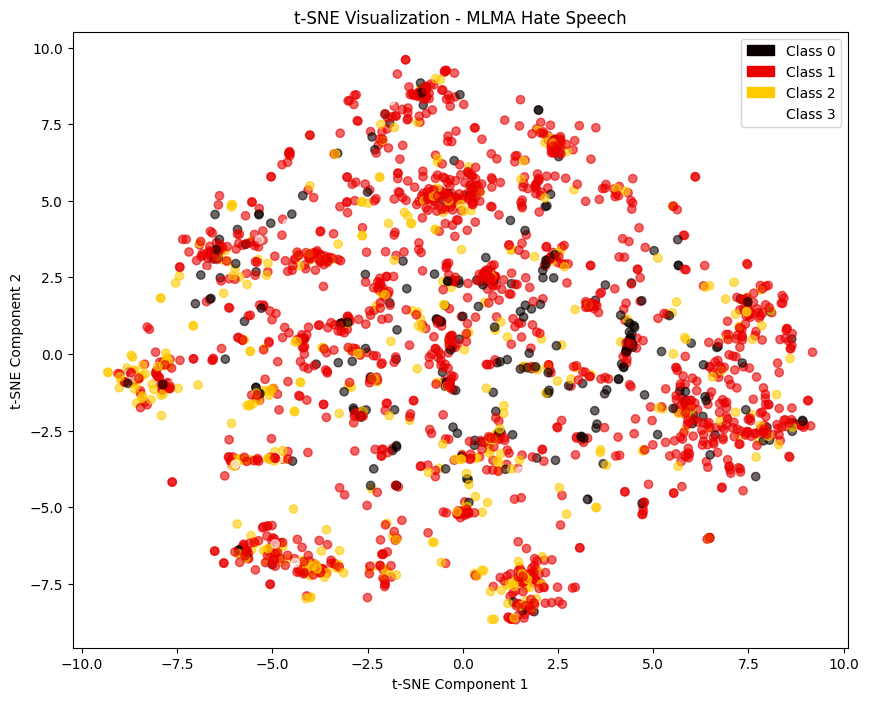

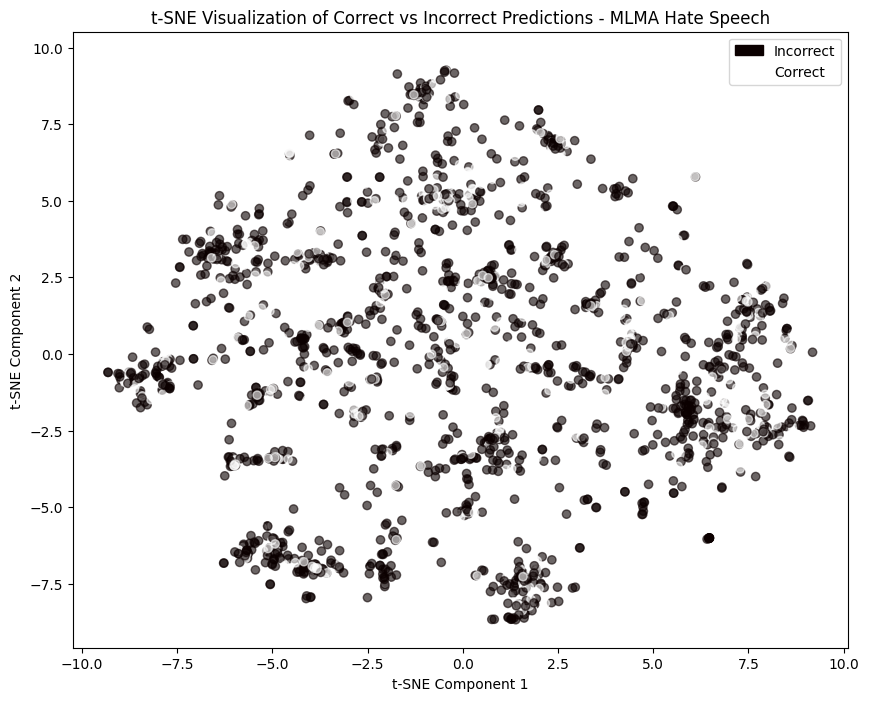

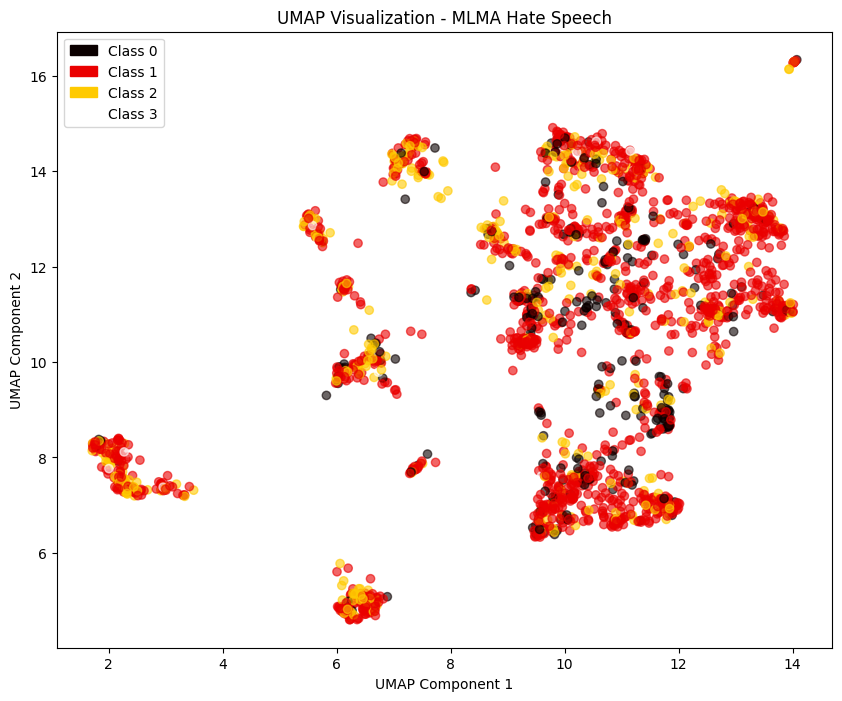

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.43481717011128773,
  0.5257649895408693,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.007277945824937569),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0),
   8: np.float64(0.019962185250604694),
   9: np.float64(0.0),
   10: np.float64(0.0),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.020213279569849966),
   15: np.float64(0.0),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.007319253120092025),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float64(0.0),
   27: np.float64(0.

In [30]:
dt_classifier_model(mlma_hate_speech_target_X_train, mlma_hate_speech_target_y_train, mlma_hate_speech_target_X_test, mlma_hate_speech_target_y_test, "MLMA Hate Speech")
dt_classification_results_list

## Support Vector Machine Conclusions

In [31]:
dt_TSNE

{'Convabuse combined': array([[  5.217759 ,   2.7459013],
        [ -3.593075 ,   1.3734593],
        [ -4.4314837,  -3.548566 ],
        ...,
        [ -6.124339 ,   1.9841036],
        [ -4.527953 ,   5.744479 ],
        [-10.35632  ,   1.1492472]], dtype=float32),
 'Convabuse prev_agent': array([[ 4.638872  , -6.228913  ],
        [-0.01543945,  7.23211   ],
        [-0.5054518 ,  4.540555  ],
        ...,
        [ 1.1050353 , -4.562198  ],
        [-6.596595  , -3.897235  ],
        [-9.808644  ,  1.8937013 ]], dtype=float32),
 'Convabuse prev_user': array([[ 2.0914376 ,  4.253983  ],
        [-4.534041  ,  4.9298573 ],
        [-4.9416766 ,  7.412168  ],
        ...,
        [-0.44875953, -2.913548  ],
        [ 3.1737158 , -0.38571182],
        [ 8.684024  , -1.5510758 ]], dtype=float32),
 'Convabuse agent': array([[  6.478847 ,  -1.2538006],
        [ -9.020539 , -10.1674385],
        [  1.5689368,   8.457626 ],
        ...,
        [ -5.0412793,   5.3918138],
        [ -4.6837

In [32]:
dt_UMAP

{'Convabuse combined': array([[ 1.2990575 ,  0.9602602 ],
        [-0.4258993 ,  7.2228527 ],
        [-1.2730256 , 13.179063  ],
        ...,
        [12.398776  ,  3.9552603 ],
        [11.3621235 ,  2.7723966 ],
        [19.23351   , -0.61813927]], dtype=float32),
 'Convabuse prev_agent': array([[-19.9967   ,   5.1298485],
        [ -3.0785491, -15.59181  ],
        [-10.157525 ,   2.0517206],
        ...,
        [  4.977028 ,  -4.497476 ],
        [ 30.964264 ,  14.893356 ],
        [  3.3825781,  20.932137 ]], dtype=float32),
 'Convabuse prev_user': array([[ 12.605826  ,   0.44966424],
        [ 13.513441  ,   4.222508  ],
        [ 23.735256  ,  15.514917  ],
        ...,
        [ 12.926139  ,   3.003311  ],
        [ 15.578077  ,   3.2724724 ],
        [ 10.557074  , -13.485095  ]], dtype=float32),
 'Convabuse agent': array([[ 18.323637 ,   6.188771 ],
        [ -9.671897 ,  15.046391 ],
        [ 10.067943 ,  -7.6878915],
        ...,
        [  7.623655 ,  16.609398 ],
     

In [33]:
# Pickle both dictionaries
with open(f'{pickle_path}decision-tree-TSNE-dict_sentiment-analysis-SMOTE.pkl', 'wb') as f:
    pickle.dump(dt_TSNE, f)
with open(f'{pickle_path}decision-tree-UMAP-dict_sentiment-analysis-SMOTE.pkl', 'wb') as f:
    pickle.dump(dt_UMAP, f)

In [34]:
dt_classification_results_list

[('Decision Tree',
  'Convabuse combined',
  'NA',
  'NA',
  0.43481717011128773,
  0.5257649895408693,
  0.0,
  {'dt_classifier__min_samples_split': 1209,
   'dt_classifier__min_samples_leaf': 403,
   'dt_classifier__max_depth': 10,
   'dt_classifier__criterion': 'gini'},
  {0: np.float64(0.0),
   1: np.float64(0.0),
   2: np.float64(0.0),
   3: np.float64(0.007277945824937569),
   4: np.float64(0.0),
   5: np.float64(0.0),
   6: np.float64(0.0),
   7: np.float64(0.0),
   8: np.float64(0.019962185250604694),
   9: np.float64(0.0),
   10: np.float64(0.0),
   11: np.float64(0.0),
   12: np.float64(0.0),
   13: np.float64(0.0),
   14: np.float64(0.020213279569849966),
   15: np.float64(0.0),
   16: np.float64(0.0),
   17: np.float64(0.0),
   18: np.float64(0.0),
   19: np.float64(0.007319253120092025),
   20: np.float64(0.0),
   21: np.float64(0.0),
   22: np.float64(0.0),
   23: np.float64(0.0),
   24: np.float64(0.0),
   25: np.float64(0.0),
   26: np.float64(0.0),
   27: np.float64(0.

In [35]:
# Convert the svm_results_list to a DataFrame
dt_classification_summary = pd.DataFrame(dt_classification_results_list, columns=["Model", "Dataset", "Kernel", "Regularization", "Accuracy", "F1-score", "Ratio", "Best Parameters", "Importances", "Top 10 Importances"])
dt_classification_summary["Balance"] = "SMOTE"
dt_classification_summary

,Model,Dataset,Kernel,Regularization,Accuracy,F1-score,Ratio,Best Parameters,Importances,Top 10 Importances,Balance
0,Decision Tree,Convabuse combined,NA,NA,0.434817,0.525765,0.0,"{'dt_classifier__min_samples_split': 1209, 'dt...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0072779458249375...","{119: 0.02367372865258096, 342: 0.029188763771...",SMOTE
1,Decision Tree,Convabuse prev_agent,NA,NA,0.337440,0.426874,0.0,"{'dt_classifier__min_samples_split': 1209, 'dt...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{70: 0.03197849873940117, 272: 0.0345592493461...",SMOTE
2,Decision Tree,Convabuse prev_user,NA,NA,0.356518,0.451840,0.0,"{'dt_classifier__min_samples_split': 1209, 'dt...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{349: 0.028410585615974083, 294: 0.02866366361...",SMOTE
3,Decision Tree,Convabuse agent,NA,NA,0.331479,0.436711,0.0,"{'dt_classifier__min_samples_split': 1209, 'dt...","{0: 0.010725698468945093, 1: 0.041263280576435...","{14: 0.03115684493252797, 148: 0.0338206099827...",SMOTE
4,Decision Tree,Convabuse user,NA,NA,0.474165,0.569291,0.0,"{'dt_classifier__min_samples_split': 1209, 'dt...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{52: 0.02651014800499396, 207: 0.0283533206687...",SMOTE
5,Decision Tree,Dynamically Generated Hate Speech target,NA,NA,0.616756,0.643552,0.0,"{'dt_classifier__min_samples_split': 1488, 'dt...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{32: 0.019649523102146804, 7: 0.02661328684297...",SMOTE
6,Decision Tree,Dynamically Generated Hate Speech label,NA,NA,0.616390,0.616893,0.0,"{'dt_classifier__min_samples_split': 1056, 'dt...","{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0....","{261: 0.025914915854471525, 99: 0.026900217847...",SMOTE
7,Decision Tree,MLMA Hate Speech,NA,NA,0.351483,0.401090,0.0,"{'dt_classifier__min_samples_split': 490, 'dt_...","{0: 0.0, 1: 0.010927005111364583, 2: 0.0, 3: 0...","{367: 0.022316309203076753, 164: 0.02392838304...",SMOTE


In [36]:
dt_classification_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/sentiment_analysis_model6_dt-classification-summary_SMOTE.csv", index=False)